# **1-hour Horizon**

### **Library Imports:**

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import logging
from scipy import stats
import seaborn as sns
from scipy.stats import ks_2samp
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import time
import joblib
import statsmodels.api as sm

# Add the parent directory to Python's path
sys.path.append(os.path.abspath('..'))

from sklearn.preprocessing import StandardScaler

# Import your custom modules
import src.config as config
from src.model_prep_tools import create_multivariate_sequences, flatten_for_ml
from src.model_architectures import run_power_lstm, run_vanilla_transformer, run_keras_patchtst, run_chronos_univariate, run_chronos2_multivariate_v2
from src.ml_baselines import xgboost_implementation, rf_implementation, run_daily_naive
from src.evaluation_utils import save_experiment_results, plot_predictions, calculate_metrics, plot_hourly_error_heatmap, plot_uncertainty_bounds, run_all_residual_diagnostics, evaluate_statistical_significance, run_statistical_significance_tests

pd.set_option('display.max_columns', 50)
plt.style.use('seaborn-v0_8-whitegrid')


# 1-HOUR HORIZON CONFIGURATION

HORIZON_NAME = "1_hour"
HORIZON_STEPS = 24
SEQ_LENGTH = 24
config.ACTIVE_HORIZON = HORIZON_NAME
config.NATIVE_FREQUENCY_MINUTES = config.FORECAST_HORIZONS[HORIZON_NAME]
config.SEQUENCE_LENGTH = HORIZON_STEPS
RANDOM_SEED = 2026

# Lock all environments using the centralized config tool!
config.set_global_seeds(RANDOM_SEED)

# Set to True to overwrite existing caches, False to load instantly
TRAIN_FROM_SCRATCH = False

2026-06-15 21:49:15,671	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-06-15 21:49:15,955	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.



Global random seeds set to 2026


In [2]:
# LOAD DATA
df_master = pd.read_parquet('../data/processed/nanogrid_60min_features.parquet')
TARGET_COL = config.TARGET_COL

# DEEP LEARNING PREP (Needs 3D continuous sequences)
dl_features = [TARGET_COL] + config.FEATURE_SETS["DEEP_LEARNING"]
df_dl = df_master[dl_features].copy()
dl_target_idx = df_dl.columns.get_loc(TARGET_COL)

# TREE PREP (Needs current snapshot + engineered lags)
tree_features = [TARGET_COL] + config.FEATURE_SETS["TREE_MODELS"]
df_tree = df_master[tree_features].copy()

# Split Indices (Strictly Chronological via Config)
total_rows = len(df_master)
train_idx = int(total_rows * config.TRAIN_SPLIT)
val_idx = int(total_rows * (config.TRAIN_SPLIT + config.VAL_SPLIT))

print(f"Master Dataset: {df_master.shape}")
print(f"DL Matrix Features: {len(dl_features)}")
print(f"Tree Matrix Features: {len(tree_features)}")

Master Dataset: (13307, 23)
DL Matrix Features: 18
Tree Matrix Features: 18


In [3]:
# EXPLICIT OVERRIDE LINKED TO CONFIG
SEQ_LENGTH = config.SEQUENCE_LENGTH
HORIZON_STEPS = config.HORIZON_STEPS[config.ACTIVE_HORIZON]

# DEEP LEARNING SCALING & SEQUENCES
dl_scaler_feat = StandardScaler()
dl_scaler_targ = StandardScaler()
df_dl_scaled = df_dl.copy()

dl_feat_cols = [c for c in df_dl.columns if c != TARGET_COL]

# Fit strictly on train, Transform the entire column safely
dl_scaler_targ.fit(df_dl.iloc[:train_idx][[TARGET_COL]])
df_dl_scaled[TARGET_COL] = dl_scaler_targ.transform(df_dl[[TARGET_COL]])

dl_scaler_feat.fit(df_dl.iloc[:train_idx][dl_feat_cols])
df_dl_scaled[dl_feat_cols] = dl_scaler_feat.transform(df_dl[dl_feat_cols])

# Generate 3D Sequences
X_train_3d, y_train = create_multivariate_sequences(df_dl_scaled.iloc[:train_idx].values, dl_target_idx, SEQ_LENGTH, HORIZON_STEPS)
X_val_3d, y_val     = create_multivariate_sequences(df_dl_scaled.iloc[train_idx:val_idx].values, dl_target_idx, SEQ_LENGTH, HORIZON_STEPS)
X_test_3d, y_test   = create_multivariate_sequences(df_dl_scaled.iloc[val_idx:].values, dl_target_idx, SEQ_LENGTH, HORIZON_STEPS)


# TREE SCALING & T-ZERO SLICE
tree_scaler_feat = StandardScaler()
df_tree_scaled = df_tree.copy()
tree_feat_cols = [c for c in df_tree.columns if c != TARGET_COL]

# Fit strictly on train, Transform the entire column safely
tree_scaler_feat.fit(df_tree.iloc[:train_idx][tree_feat_cols])
df_tree_scaled[tree_feat_cols] = tree_scaler_feat.transform(df_tree[tree_feat_cols])

# Generate sequences to match y_targets perfectly, but only keep the T=0 row
X_train_tree_temp, _ = create_multivariate_sequences(df_tree_scaled.iloc[:train_idx].values, 0, SEQ_LENGTH, HORIZON_STEPS)
X_val_tree_temp, _   = create_multivariate_sequences(df_tree_scaled.iloc[train_idx:val_idx].values, 0, SEQ_LENGTH, HORIZON_STEPS)
X_test_tree_temp, _  = create_multivariate_sequences(df_tree_scaled.iloc[val_idx:].values, 0, SEQ_LENGTH, HORIZON_STEPS)

# The T-Zero Slice
X_train_tree = X_train_tree_temp[:, -1, :]
X_val_tree   = X_val_tree_temp[:, -1, :]
X_test_tree  = X_test_tree_temp[:, -1, :]

print(f"Deep Learning Inputs (3D): Train {X_train_3d.shape} | Val {X_val_3d.shape} | Test {X_test_3d.shape}")
print(f"Tree Inputs (2D): Train {X_train_tree.shape} | Val {X_val_tree.shape} | Test {X_test_tree.shape}")
print(f"Universal Targets (y): Train {y_train.shape} | Val {y_val.shape} | Test {y_test.shape}")

# Initialize the master leaderboard list
if 'horizon_metrics' not in locals():
    horizon_metrics = []

# Lock seeds
config.set_global_seeds(config.RANDOM_SEED)

Deep Learning Inputs (3D): Train (9267, 24, 18) | Val (1284, 24, 18) | Test (2615, 24, 18)
Tree Inputs (2D): Train (9267, 18) | Val (1284, 18) | Test (2615, 18)
Universal Targets (y): Train (9267, 24) | Val (1284, 24) | Test (2615, 24)
Global random seeds set to 2026


In [4]:
time_diff = df_master.index[1] - df_master.index[0]
print(f"Current df_master frequency: {time_diff}")
print(f"Total rows: {len(df_master)}")

Current df_master frequency: 0 days 01:00:00
Total rows: 13307


## **Naive Baseline**

Running Daily Naive Baseline for 1_hour (24 steps)
Daily_Naive_Baseline artifacts successfully saved to ../results/1_hour/Daily_Naive_Baseline/


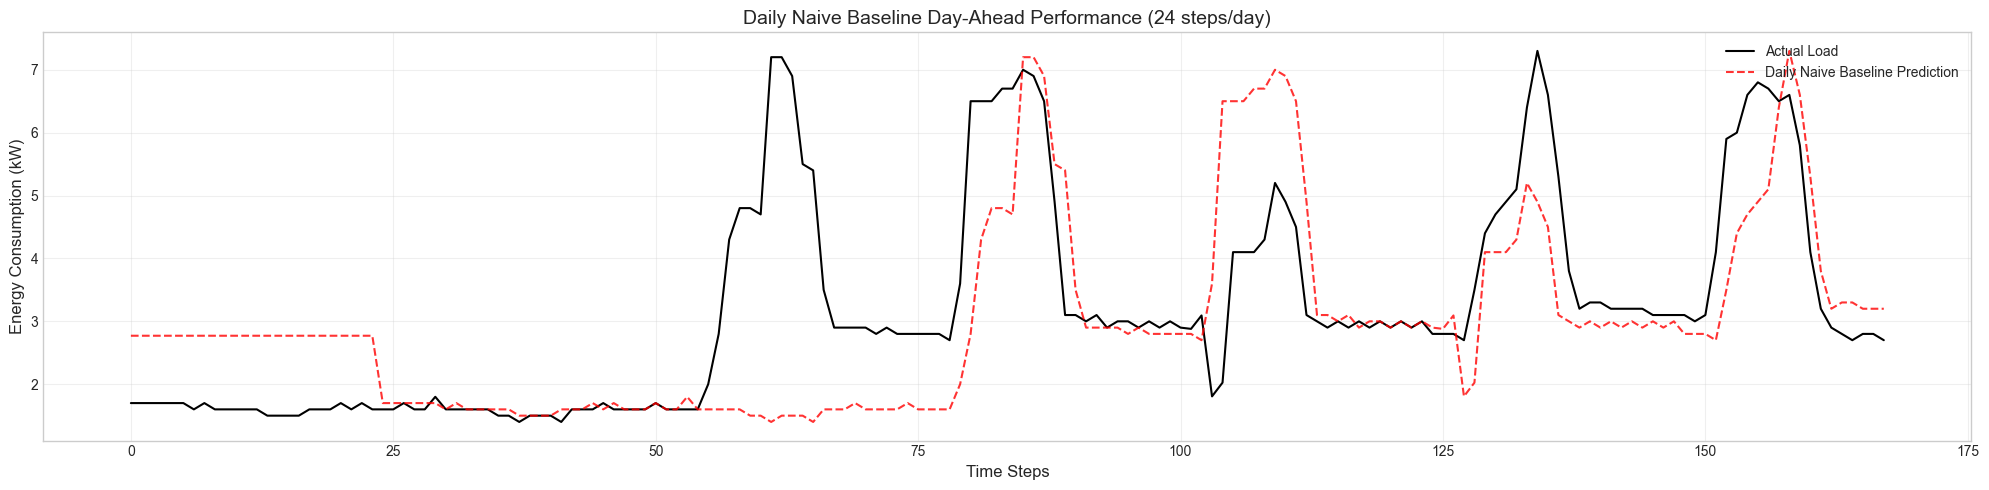

In [5]:
# NAIVE BASELINE
y_train_raw = df_master.iloc[:train_idx][TARGET_COL].values

# Safely reshape for the scaler to prevent ValueError, then restore matrix shape
orig_shape = y_test.shape
y_test_unscaled = dl_scaler_targ.inverse_transform(y_test.reshape(-1, 1)).reshape(orig_shape)

print(f"Running Daily Naive Baseline for {HORIZON_NAME} ({HORIZON_STEPS} steps)")

start_time = time.time()
naive_predictions = run_daily_naive(y_test_unscaled, horizon=HORIZON_STEPS)
exec_time = time.time() - start_time

naive_metrics = calculate_metrics(
    y_true=y_test_unscaled, 
    y_pred=naive_predictions, 
    model_name="Daily_Naive_Baseline", 
    execution_time=exec_time,
    horizon=HORIZON_STEPS, 
    y_train=y_train_raw 
)

naive_results_dict = {
    "model": "Daily_Naive",
    "predictions": naive_predictions,
    "y_test_real": y_test_unscaled,
    "metrics": naive_metrics
}

save_experiment_results(
    results_dict=naive_results_dict, 
    model_name="Daily_Naive_Baseline", 
    horizon_name=HORIZON_NAME,
    y_test=y_test_unscaled, 
    horizon=HORIZON_STEPS
)

horizon_metrics.append(naive_metrics)

plot_predictions(
    y_true=y_test_unscaled, 
    y_pred=naive_predictions, 
    model_name="Daily Naive Baseline", 
    horizon=HORIZON_STEPS,
    num_steps=HORIZON_STEPS * 7
)

## **Tree Ensemble Methods**


RUNNING XGBOOST_MAE (1_hour) | Horizon: 24
Loading pre-trained model from ../results/1_hour/XGBoost_MAE/xgboost_mae_model.joblib


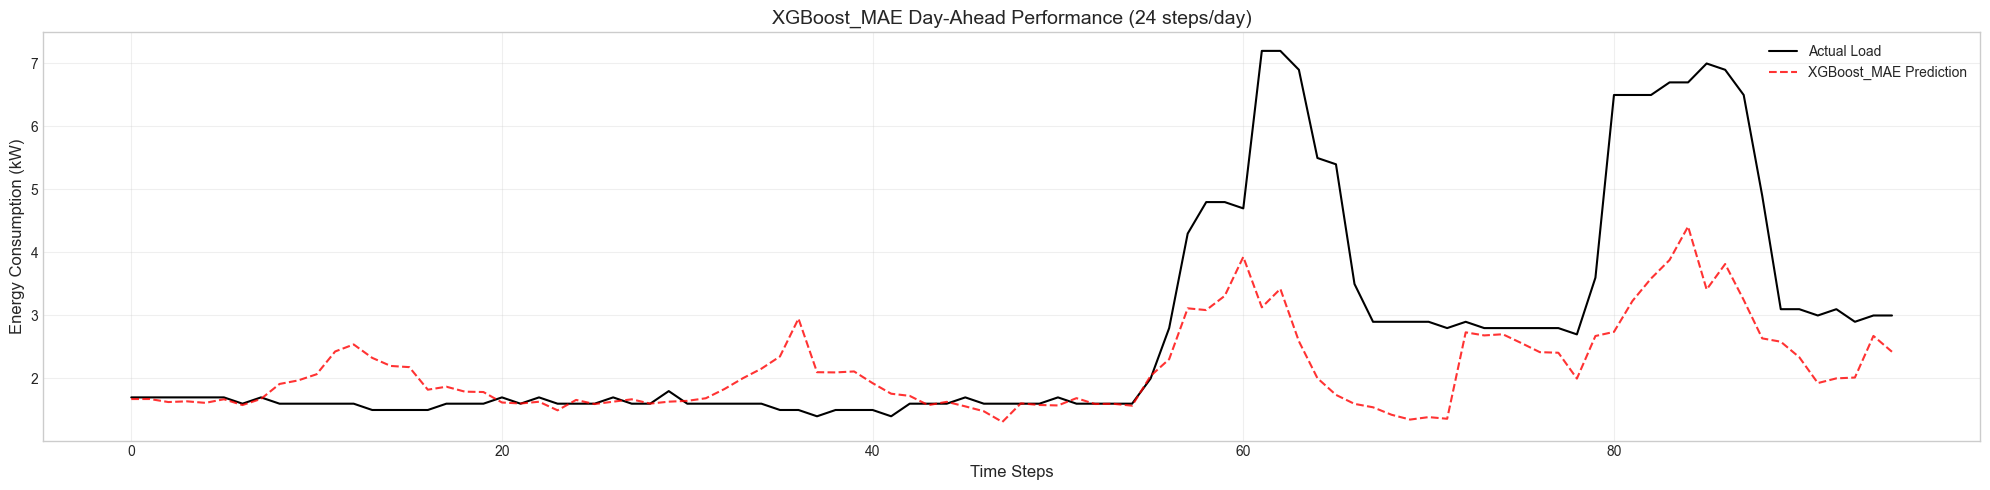

XGBoost_MAE artifacts successfully saved to ../results/1_hour/XGBoost_MAE/

RUNNING XGBOOST_RMSE (1_hour) | Horizon: 24
Loading pre-trained model from ../results/1_hour/XGBoost_RMSE/xgboost_rmse_model.joblib


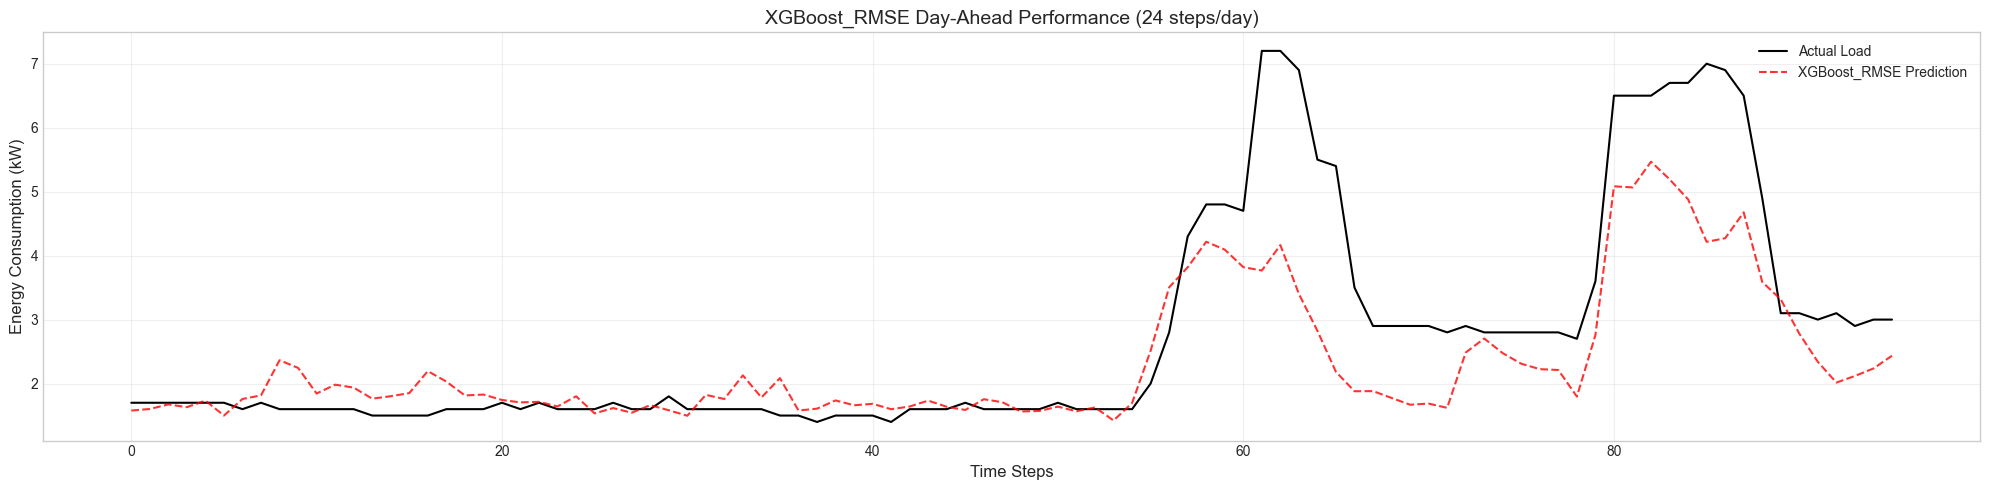

XGBoost_RMSE artifacts successfully saved to ../results/1_hour/XGBoost_RMSE/

 RUNNING RANDOM_FOREST (1_hour) | Horizon: 24
Loading pre-trained model from ../results/1_hour/Random_Forest/random_forest_model.joblib


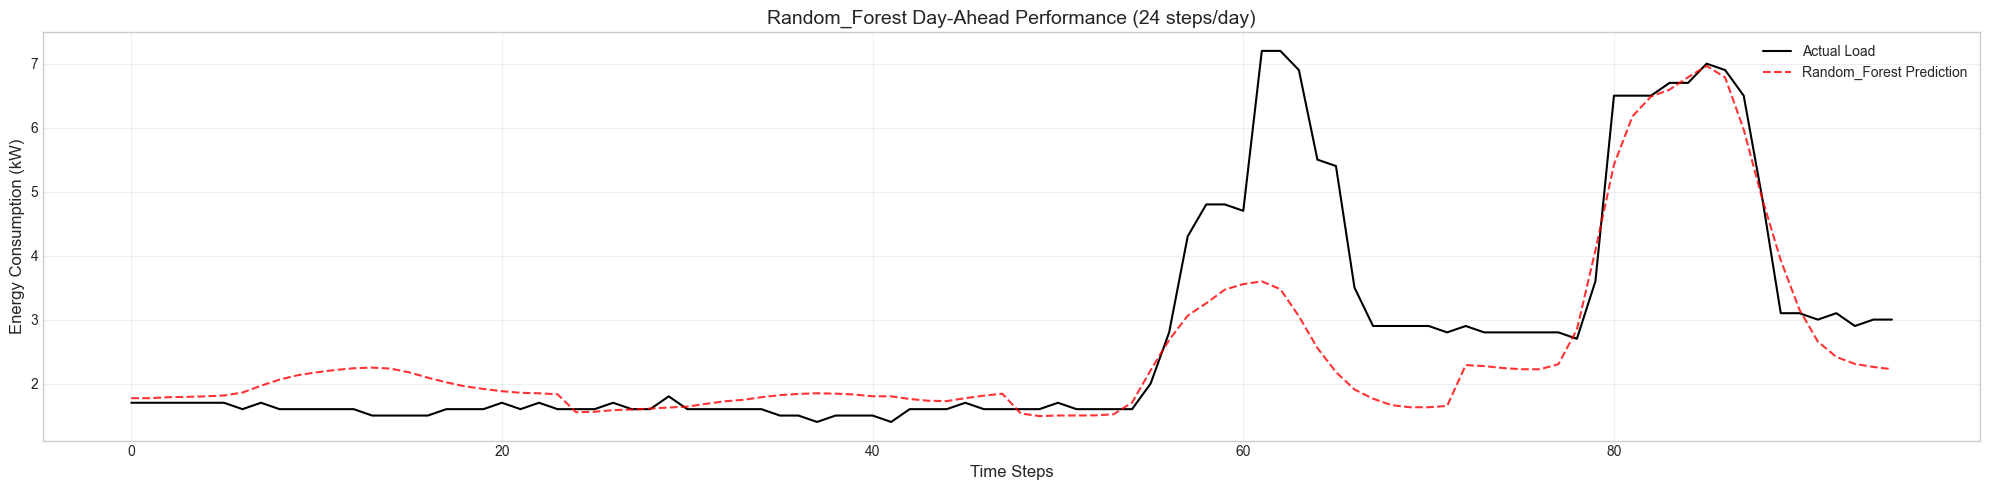

Random_Forest artifacts successfully saved to ../results/1_hour/Random_Forest/

Loading XGBoost_MAE from cache...


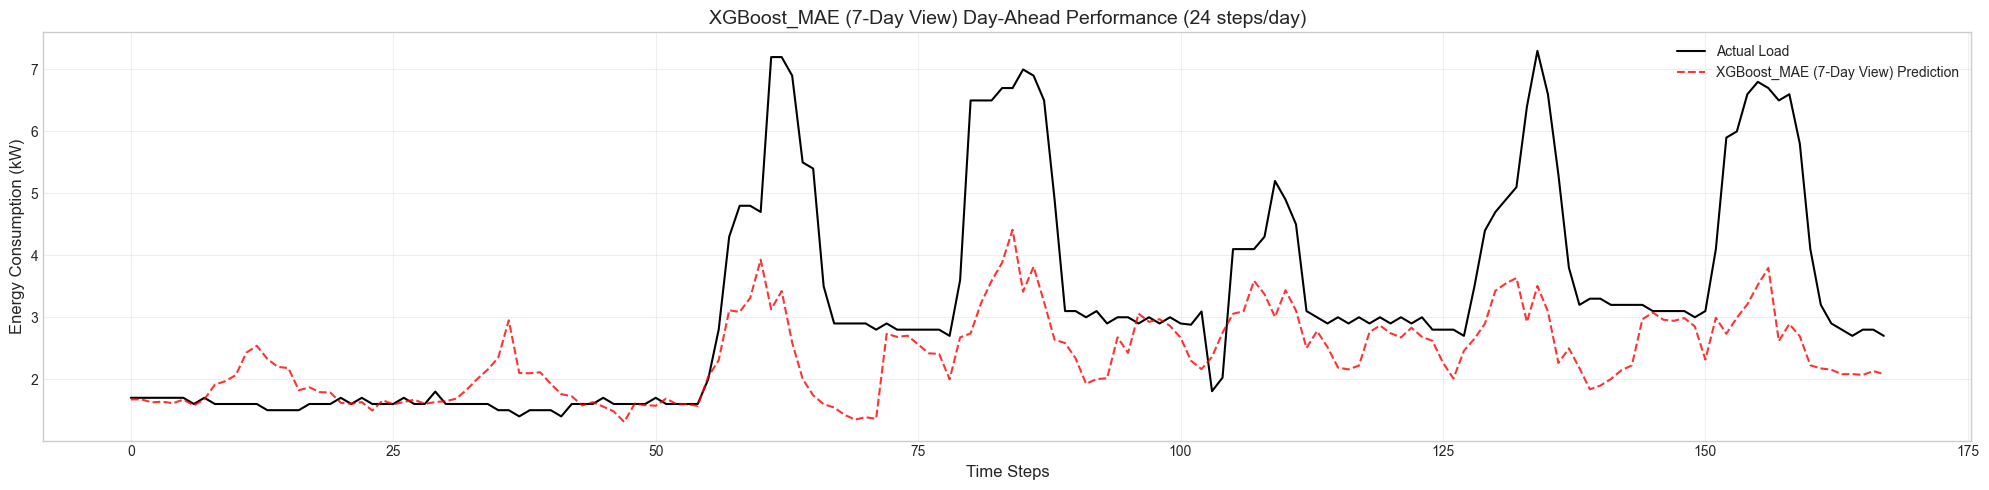


Loading XGBoost_RMSE from cache...


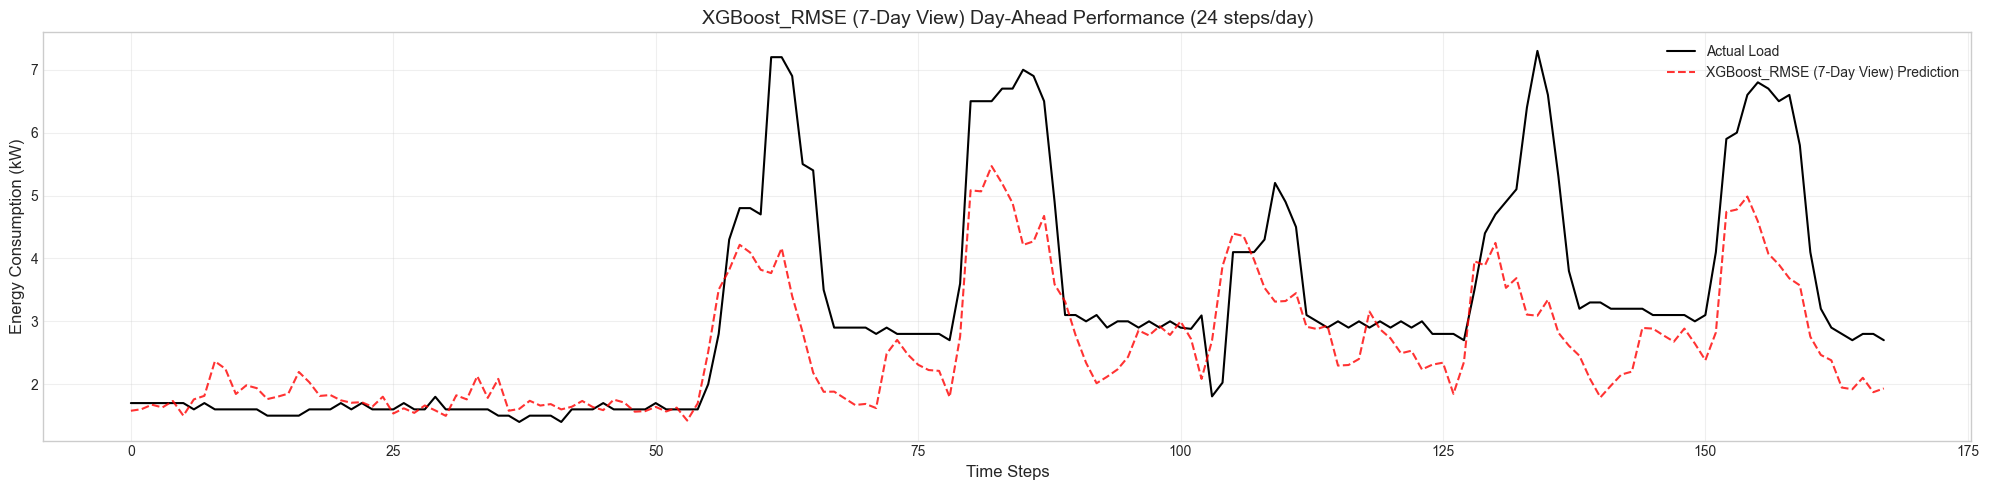


Loading Random_Forest from cache...


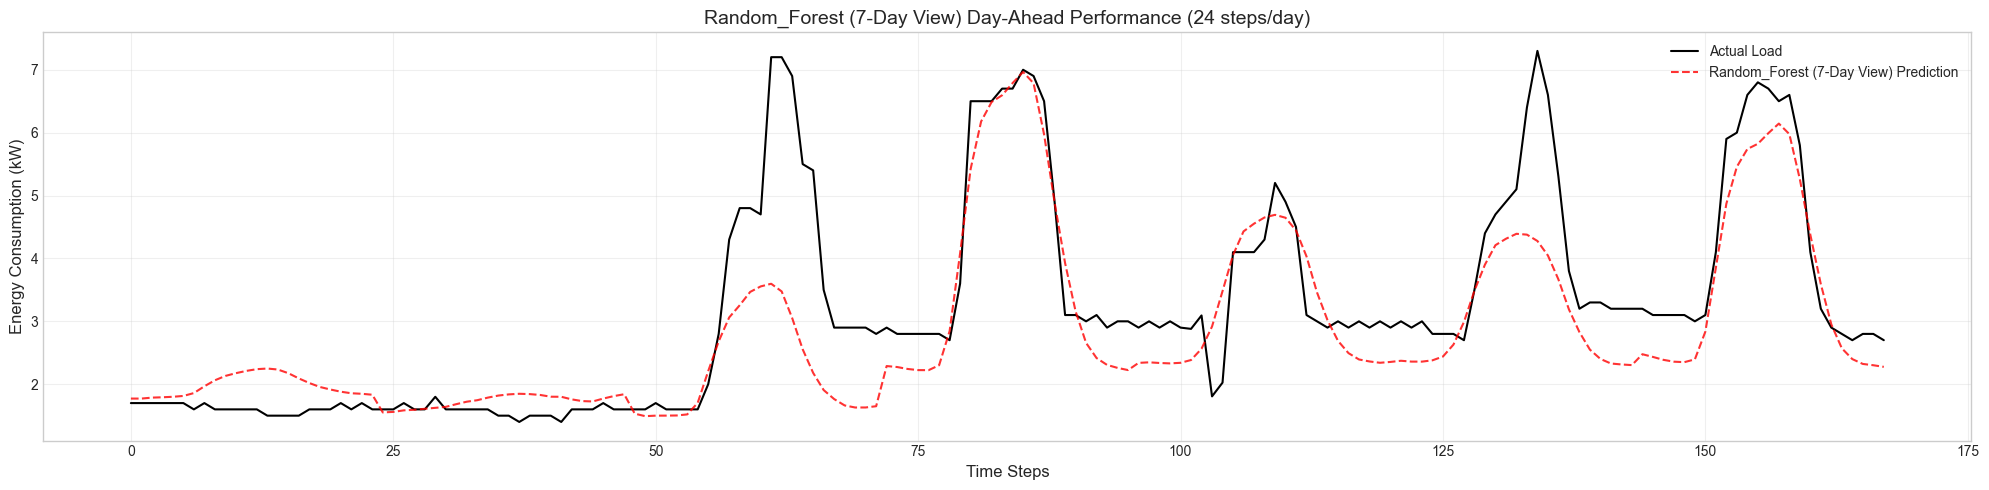

In [ ]:
xgboost_experiments = ["MAE", "RMSE"]

for metric in xgboost_experiments:
    results = xgboost_implementation(
        X_train=X_train_tree, y_train=y_train,
        X_val=X_val_tree, y_val=y_val,
        X_test=X_test_tree, y_test=y_test,
        horizon_name=HORIZON_NAME,
        y_train_full=y_train,
        target_scaler=dl_scaler_targ,
        target_feature_idx=0,
        optimization_metric=metric,
        train_from_scratch=TRAIN_FROM_SCRATCH
    )
    
    # Use continuous 1D array for proper MASE denominator
    continuous_y_train = df_dl_scaled.iloc[:train_idx, 0].values 
    if dl_scaler_targ is not None:
        y_train_unscaled = dl_scaler_targ.inverse_transform(continuous_y_train.reshape(-1, 1)).flatten()
    else:
        y_train_unscaled = continuous_y_train.flatten()
        
    # Extract execution time
    old_time = results.get('execution_time', results.get('metrics', {}).get('Time (s)', 0.0))
        
    # Calculate Metrics with unscaled continuous y_train
    true_metrics = calculate_metrics(
        y_true=results['y_test_real'], 
        y_pred=results['predictions'], 
        model_name=f"XGBoost_{metric}", 
        execution_time=old_time, 
        horizon=HORIZON_STEPS, 
        y_train=y_train_unscaled
    )
    
    results['metrics'] = true_metrics
    
    # Save Artifacts
    save_experiment_results(
        results_dict=results, 
        model_name=f"XGBoost_{metric}", 
        horizon_name=HORIZON_NAME, 
        y_test=results['y_test_real'], 
        horizon=HORIZON_STEPS
    )

    # Append to leaderboard
    horizon_metrics.append(true_metrics)

results_rf = rf_implementation(
    X_train=X_train_tree, y_train=y_train,
    X_val=X_val_tree, y_val=y_val,
    X_test=X_test_tree, y_test=y_test,
    horizon_name=HORIZON_NAME,
    y_train_full=y_train,
    target_scaler=dl_scaler_targ,
    target_feature_idx=0,
    train_from_scratch=TRAIN_FROM_SCRATCH
)

# Random Forest
continuous_y_train_rf = df_dl_scaled.iloc[:train_idx, 0].values
if dl_scaler_targ is not None:
    y_train_unscaled_rf = dl_scaler_targ.inverse_transform(continuous_y_train_rf.reshape(-1, 1)).flatten()
else:
    y_train_unscaled_rf = continuous_y_train_rf.flatten()

# Extract execution time
old_time_rf = results_rf.get('execution_time', results_rf.get('metrics', {}).get('Time (s)', 0.0))

# Calculate Metrics with unscaled continuous y_train
true_metrics_rf = calculate_metrics(
    y_true=results_rf['y_test_real'], 
    y_pred=results_rf['predictions'], 
    model_name="Random_Forest", 
    execution_time=old_time_rf, 
    horizon=HORIZON_STEPS, 
    y_train=y_train_unscaled_rf
)

results_rf['metrics'] = true_metrics_rf

# Save Artifacts
save_experiment_results(
    results_dict=results_rf, 
    model_name="Random_Forest", 
    horizon_name=HORIZON_NAME, 
    y_test=results_rf['y_test_real'], 
    horizon=HORIZON_STEPS
)

# Append to leaderboard
horizon_metrics.append(true_metrics_rf)

tree_models = [
    {"folder": "XGBoost_MAE", "file": "xgboost_mae_model.joblib"},
    {"folder": "XGBoost_RMSE", "file": "xgboost_rmse_model.joblib"},
    {"folder": "Random_Forest", "file": "random_forest_model.joblib"}
]

# Loop, Load, Predict and Plot
for model_info in tree_models:
    folder_name = model_info["folder"]
    file_name = model_info["file"]
    
    model_save_path = f"../results/{HORIZON_NAME}/{folder_name}/{file_name}"
    
    try:
        print(f"\nLoading {folder_name} from cache...")
        cached_model = joblib.load(model_save_path)
        
        # Feed the exact 2D tree matrix it was trained on
        test_preds = cached_model.predict(X_test_tree)
        
        # Inverse Scale back to kW safely
        orig_shape = test_preds.shape
        test_preds_unscaled = dl_scaler_targ.inverse_transform(test_preds.reshape(-1, 1)).reshape(orig_shape)
        y_test_unscaled = dl_scaler_targ.inverse_transform(y_test.reshape(-1, 1)).reshape(orig_shape)
        
        # Plot 7 Days
        plot_predictions(
            y_true=y_test_unscaled, 
            y_pred=test_preds_unscaled, 
            model_name=f"{folder_name} (7-Day View)", 
            horizon=HORIZON_STEPS,
            num_steps=HORIZON_STEPS * 7
        )
    except FileNotFoundError:
        print(f"Could not find cached model at {model_save_path}.")

## **Deep Learning Architectures:**

### **LSTM Experiments:**


Running Power_LSTM_Standard_Capacity

 RUNNING POWER_LSTM_STANDARD_CAPACITY (1_hour) | Horizon: 24
Cache found! Loading cached inferences from ../results/1_hour/Power_LSTM_Standard_Capacity\predictions.npz
Power_LSTM_Standard_Capacity artifacts successfully saved to ../results/1_hour/Power_LSTM_Standard_Capacity/
Power_LSTM_Standard_Capacity added to leaderboard! (MASE: 0.896)


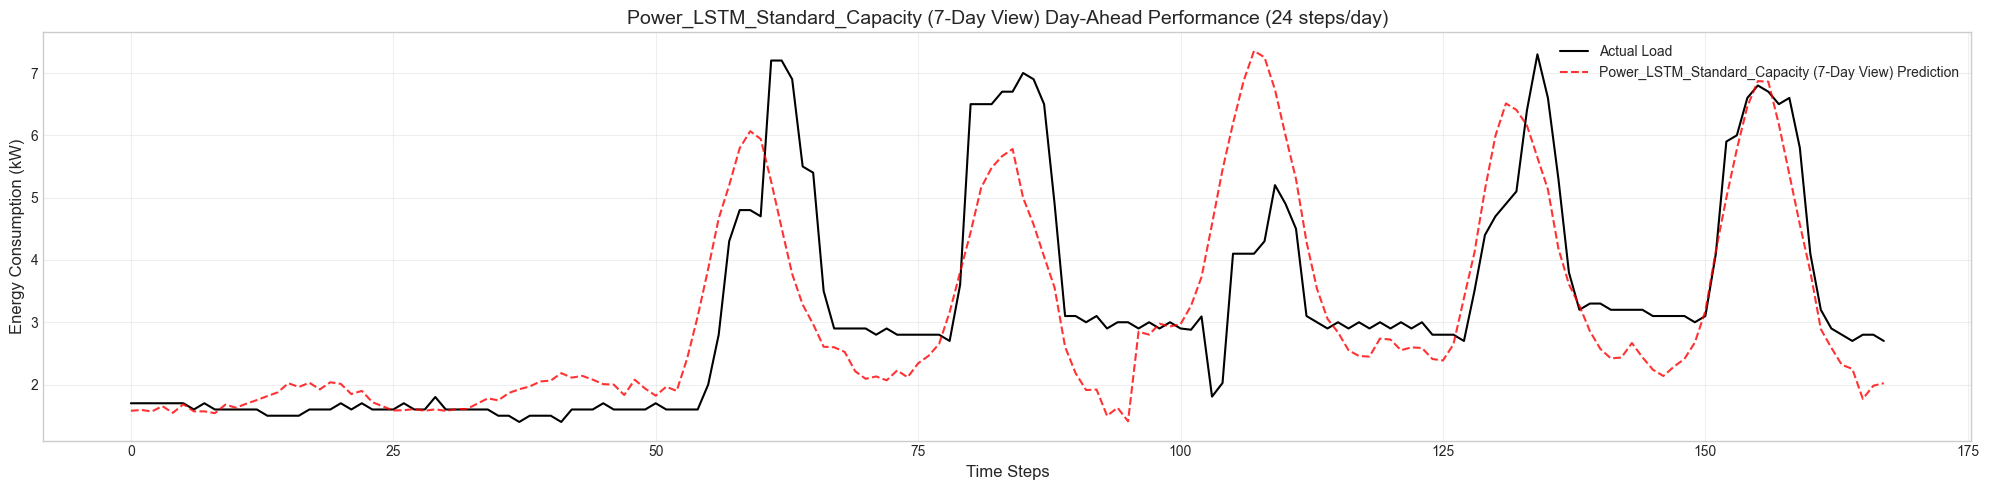


Running Power_LSTM_High_Capacity

 RUNNING POWER_LSTM_HIGH_CAPACITY (1_hour) | Horizon: 24
Cache found! Loading cached inferences from ../results/1_hour/Power_LSTM_High_Capacity\predictions.npz
Power_LSTM_High_Capacity artifacts successfully saved to ../results/1_hour/Power_LSTM_High_Capacity/
Power_LSTM_High_Capacity added to leaderboard! (MASE: 0.937)


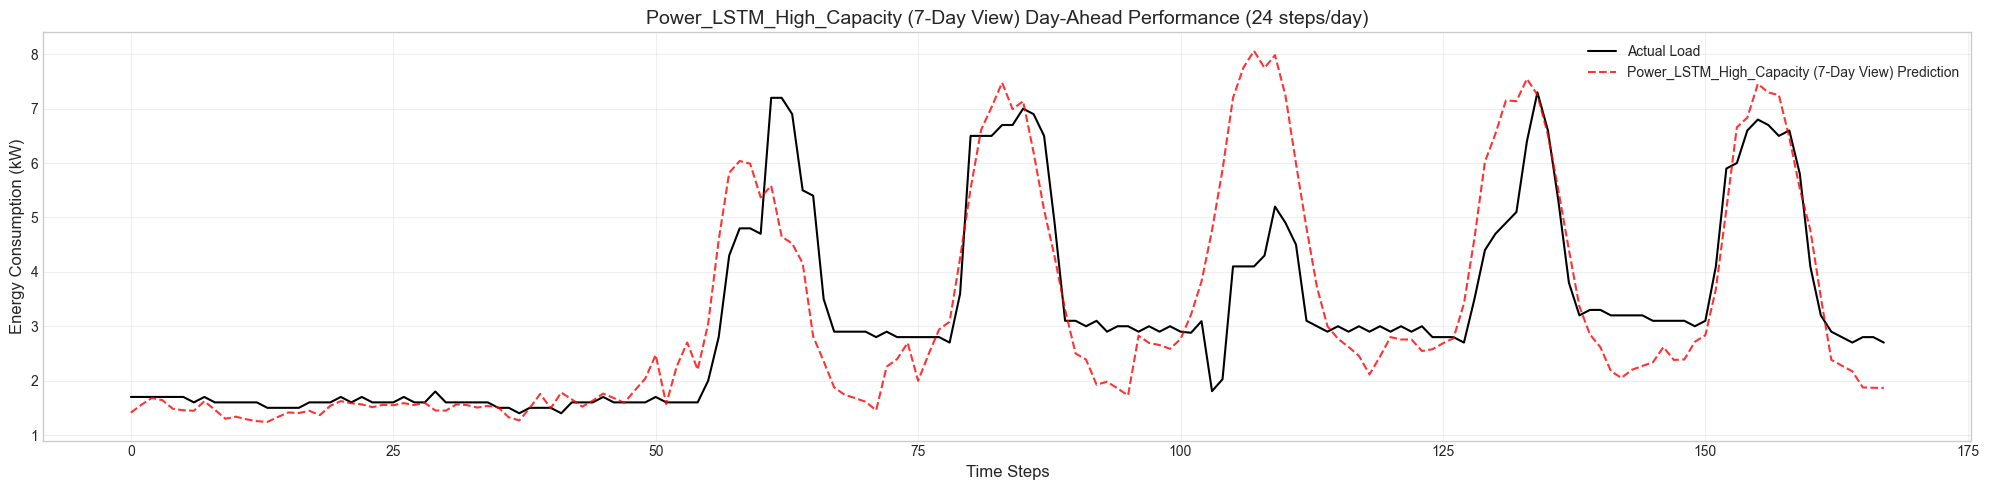


Running LSTM_Wide_MSE

 RUNNING LSTM_WIDE_MSE (1_hour) | Horizon: 24
Cache found! Loading cached inferences from ../results/1_hour/LSTM_Wide_MSE\predictions.npz
LSTM_Wide_MSE artifacts successfully saved to ../results/1_hour/LSTM_Wide_MSE/
LSTM_Wide_MSE added to leaderboard! (MASE: 0.891)


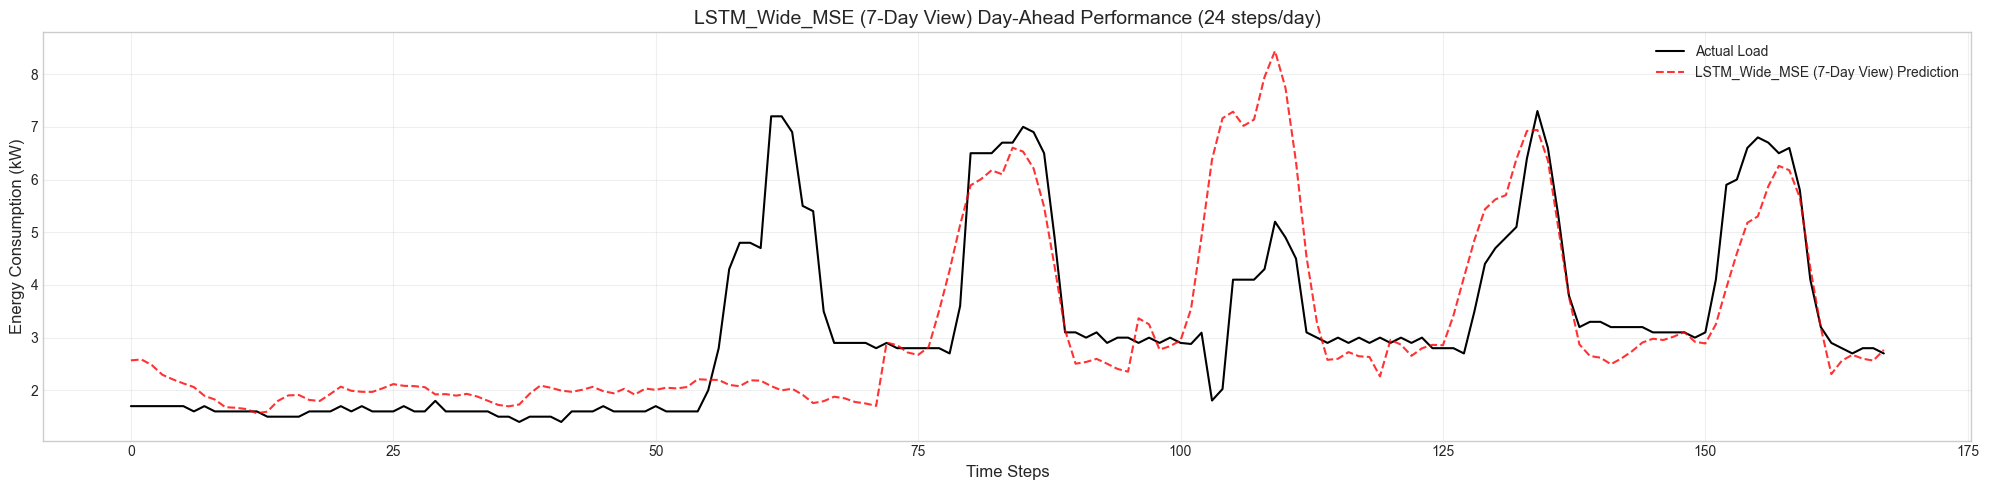

In [ ]:
original_lstm_config = config.LSTM_CONFIG.copy()

lstm_experiments = [
    {
        "name": "Power_LSTM_Standard_Capacity", 
        "hidden_units": [64, 32], 
        "dropout": 0.2,
        "loss": "huber"
    },
    {
        "name": "Power_LSTM_High_Capacity", 
        "hidden_units": [128, 64], 
        "dropout": 0.4,
        "loss": "huber"
    },
    {
        "name": "LSTM_Wide_MSE", 
        "hidden_units": [128, 96], 
        "dropout": 0.2,
        "loss": "mse"
    }
]

epochs = config.TRAINING_PARAMS["epochs"]
batch_size = config.TRAINING_PARAMS["batch_size"]

y_train_raw = df_master.iloc[:train_idx][TARGET_COL].values

for exp in lstm_experiments:
    exp_name = exp["name"]
    print(f"\nRunning {exp_name}")
    
    config.LSTM_CONFIG["hidden_units"] = exp["hidden_units"]
    config.LSTM_CONFIG["dropout"] = exp["dropout"]
    config.LSTM_CONFIG["loss"] = exp["loss"]
    
    results = run_power_lstm(
        X_train=X_train_3d, y_train=y_train, 
        X_val=X_val_3d, y_val=y_val, 
        X_test=X_test_3d, y_test=y_test, 
        horizon_name=HORIZON_NAME, 
        horizon=HORIZON_STEPS, 
        epochs=epochs, 
        batch_size=batch_size, 
        random_state=config.RANDOM_SEED,
        experiment_name=exp_name,
        target_scaler=dl_scaler_targ,
        train_from_scratch=TRAIN_FROM_SCRATCH
    )
    
    # Extract execution time
    old_time = results.get('execution_time', results.get('metrics', {}).get('Time (s)', 0.0))
    
    # recalculate metrics with 1D y_train_raw
    true_metrics = calculate_metrics(
        y_true=results['y_test_real'], 
        y_pred=results['predictions'], 
        model_name=exp_name, 
        execution_time=old_time, 
        horizon=HORIZON_STEPS, 
        y_train=y_train_raw
    )
    
    results['metrics'] = true_metrics
    
    # Save Artifacts
    save_experiment_results(
        results_dict=results, 
        model_name=exp_name, 
        horizon_name=HORIZON_NAME, 
        y_test=results['y_test_real'], 
        horizon=HORIZON_STEPS
    )
    
    # Append to leaderboard
    horizon_metrics.append(true_metrics)
    print(f"{exp_name} added to leaderboard! (MASE: {true_metrics['MASE']:.3f})")
    
    plot_predictions(
        y_true=results['y_test_real'], 
        y_pred=results['predictions'], 
        model_name=f"{exp_name} (7-Day View)", 
        horizon=HORIZON_STEPS,
        num_steps=HORIZON_STEPS * 7 
    )

config.LSTM_CONFIG = original_lstm_config

### **Vanila Transformer Experiments:**

Generating 48-step (2-Day) matrices for deep context testing
1-Day Test Targets: 2615
2-Day Test Targets: 2591

Running Vanilla_Transformer_1Day_Context (Sequence: 24)

RUNNING VANILLA_TRANSFORMER_1DAY_CONTEXT (1_hour) | Horizon: 24
Loading cached inferences from ../results/1_hour/Vanilla_Transformer_1Day_Context\predictions.npz
Vanilla_Transformer_1Day_Context artifacts successfully saved to ../results/1_hour/Vanilla_Transformer_1Day_Context/
Vanilla_Transformer_1Day_Context added to leaderboard (MASE: 0.802)


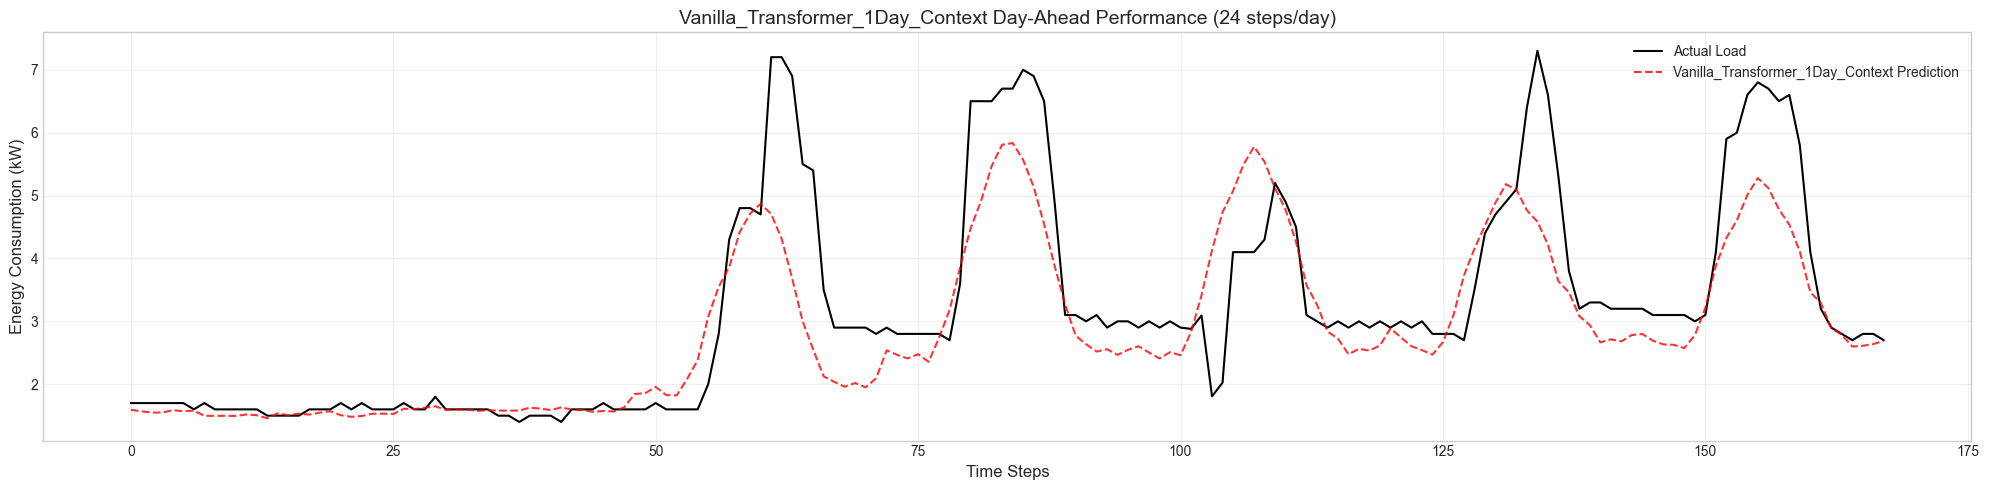


Running Vanilla_Transformer_2Day_Context (Sequence: 48)

RUNNING VANILLA_TRANSFORMER_2DAY_CONTEXT (1_hour) | Horizon: 24
Loading cached inferences from ../results/1_hour/Vanilla_Transformer_2Day_Context\predictions.npz
Vanilla_Transformer_2Day_Context artifacts successfully saved to ../results/1_hour/Vanilla_Transformer_2Day_Context/
Vanilla_Transformer_2Day_Context added to leaderboard (MASE: 0.860)


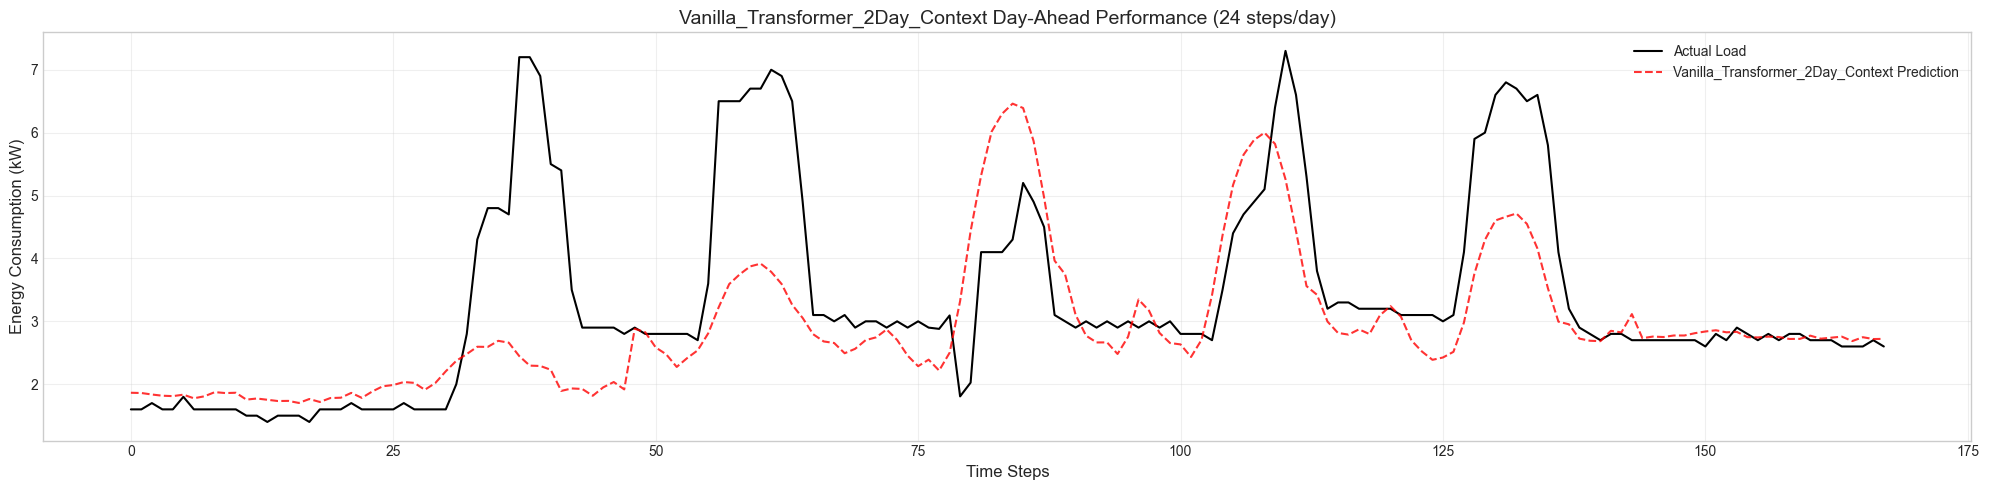

In [ ]:
print("Generating 48-step (2-Day) matrices for deep context testing")
SEQ_LENGTH_2DAY = 48

X_train_2day, y_train_2day = create_multivariate_sequences(df_dl_scaled.iloc[:train_idx].values, dl_target_idx, SEQ_LENGTH_2DAY, HORIZON_STEPS)
X_val_2day, y_val_2day     = create_multivariate_sequences(df_dl_scaled.iloc[train_idx:val_idx].values, dl_target_idx, SEQ_LENGTH_2DAY, HORIZON_STEPS)
X_test_2day, y_test_2day   = create_multivariate_sequences(df_dl_scaled.iloc[val_idx:].values, dl_target_idx, SEQ_LENGTH_2DAY, HORIZON_STEPS)

print(f"1-Day Test Targets: {y_test.shape[0]}")
print(f"2-Day Test Targets: {y_test_2day.shape[0]}")

transformer_experiments = [
    {
        "name": "Vanilla_Transformer_1Day_Context",
        "X_train": X_train_3d, "y_train": y_train,
        "X_val": X_val_3d, "y_val": y_val,
        "X_test": X_test_3d, "y_test": y_test,
        "seq_len": 24
    },
    {
        "name": "Vanilla_Transformer_2Day_Context",
        "X_train": X_train_2day, "y_train": y_train_2day,
        "X_val": X_val_2day, "y_val": y_val_2day,
        "X_test": X_test_2day, "y_test": y_test_2day,
        "seq_len": 48
    }
]

epochs = config.TRAINING_PARAMS["epochs"]
batch_size = config.TRAINING_PARAMS["batch_size"]

# Use 1D raw history for the MASE denominator
y_train_raw = df_master.iloc[:train_idx][TARGET_COL].values

for exp in transformer_experiments:
    exp_name = exp["name"]
    print(f"\nRunning {exp_name} (Sequence: {exp['seq_len']})")
    
    results = run_vanilla_transformer(
        X_train=exp["X_train"], y_train=exp["y_train"], 
        X_val=exp["X_val"], y_val=exp["y_val"], 
        X_test=exp["X_test"], y_test=exp["y_test"], 
        horizon_name=HORIZON_NAME, 
        horizon=HORIZON_STEPS, 
        epochs=epochs, 
        batch_size=batch_size, 
        random_state=config.RANDOM_SEED, 
        experiment_name=exp_name,
        target_scaler=dl_scaler_targ,
        train_from_scratch=TRAIN_FROM_SCRATCH
    )
    
    # Extract execution time
    old_time = results.get('execution_time', results.get('metrics', {}).get('Time (s)', 0.0))
    
    # recalculate metrics with pure 1D y_train_raw
    true_metrics = calculate_metrics(
        y_true=results['y_test_real'], 
        y_pred=results['predictions'], 
        model_name=exp_name, 
        execution_time=old_time, 
        horizon=HORIZON_STEPS, 
        y_train=y_train_raw 
    )
    
    results['metrics'] = true_metrics
    
    # Save Artifacts
    save_experiment_results(
        results_dict=results, 
        model_name=exp_name, 
        horizon_name=HORIZON_NAME, 
        y_test=results['y_test_real'], 
        horizon=HORIZON_STEPS
    )
    
    # Append to leaderboard
    horizon_metrics.append(true_metrics)
    print(f"{exp_name} added to leaderboard (MASE: {true_metrics['MASE']:.3f})")
    
    plot_predictions(
        y_true=results['y_test_real'], 
        y_pred=results['predictions'], 
        model_name=exp_name, 
        horizon=HORIZON_STEPS,
        num_steps=HORIZON_STEPS * 7 
    )

### **PatchTST Experiments:**


Running PatchTST_1Day_2Hr_Patches (Sequence: 24 | Patch: 2)

RUNNING PATCHTST_1DAY_2HR_PATCHES (1_hour) | Horizon: 24
Loading cached inferences from ../results/1_hour/PatchTST_1Day_2Hr_Patches\predictions.npz
PatchTST_1Day_2Hr_Patches artifacts successfully saved to ../results/1_hour/PatchTST_1Day_2Hr_Patches/
PatchTST_1Day_2Hr_Patches added to leaderboard (MASE: 0.847)


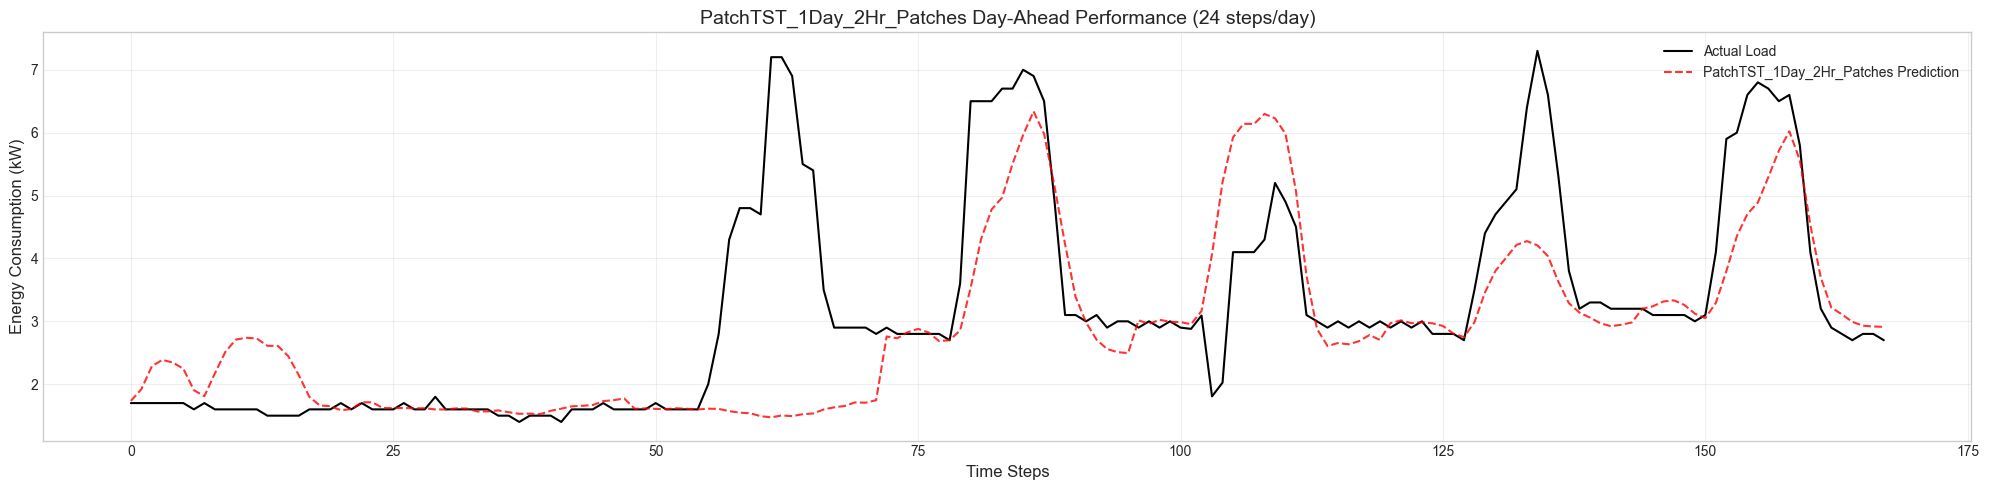


Running PatchTST_2Day_2Hr_Patches (Sequence: 48 | Patch: 2)

RUNNING PATCHTST_2DAY_2HR_PATCHES (1_hour) | Horizon: 24
Loading cached inferences from ../results/1_hour/PatchTST_2Day_2Hr_Patches\predictions.npz
PatchTST_2Day_2Hr_Patches artifacts successfully saved to ../results/1_hour/PatchTST_2Day_2Hr_Patches/
PatchTST_2Day_2Hr_Patches added to leaderboard (MASE: 0.884)


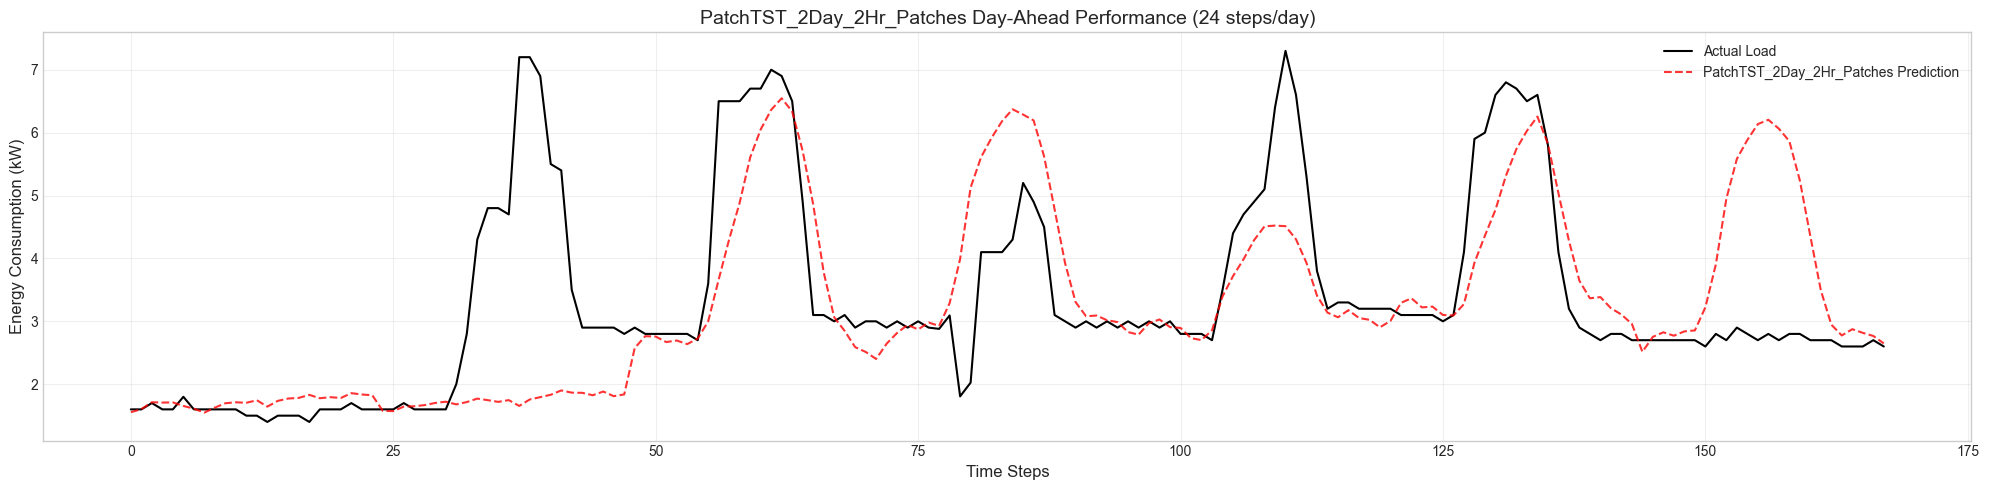


Running PatchTST_2Day_4Hr_Patches (Sequence: 48 | Patch: 4)

RUNNING PATCHTST_2DAY_4HR_PATCHES (1_hour) | Horizon: 24
Loading cached inferences from ../results/1_hour/PatchTST_2Day_4Hr_Patches\predictions.npz
PatchTST_2Day_4Hr_Patches artifacts successfully saved to ../results/1_hour/PatchTST_2Day_4Hr_Patches/
PatchTST_2Day_4Hr_Patches added to leaderboard (MASE: 0.904)


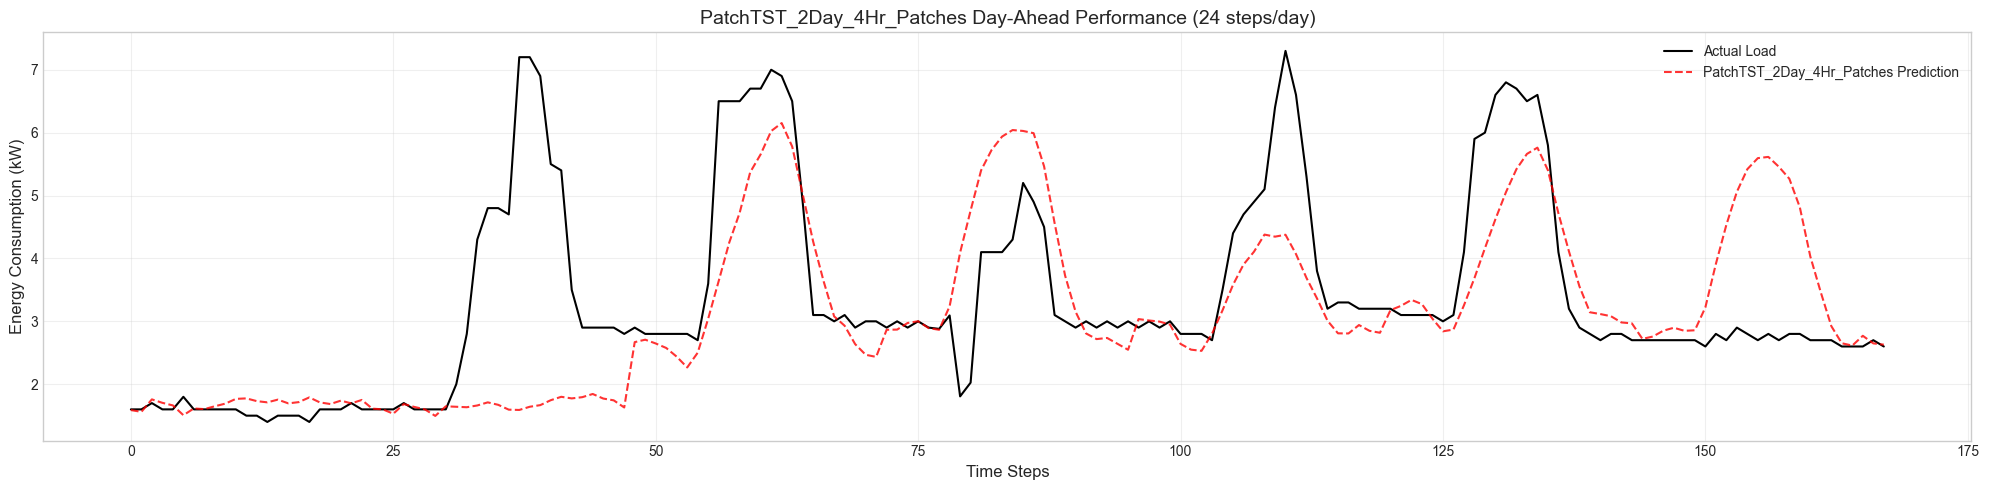

In [ ]:
patch_experiments = [
    {
        "name": "PatchTST_1Day_2Hr_Patches",
        "X_train": X_train_3d, "y_train": y_train,
        "X_val": X_val_3d, "y_val": y_val,
        "X_test": X_test_3d, "y_test": y_test,
        "seq_len": 24, "patch_len": 2, "stride": 2
    },
    {
        "name": "PatchTST_2Day_2Hr_Patches",
        "X_train": X_train_2day, "y_train": y_train_2day,
        "X_val": X_val_2day, "y_val": y_val_2day,
        "X_test": X_test_2day, "y_test": y_test_2day,
        "seq_len": 48, "patch_len": 2, "stride": 2
    },
    {
        "name": "PatchTST_2Day_4Hr_Patches",
        "X_train": X_train_2day, "y_train": y_train_2day,
        "X_val": X_val_2day, "y_val": y_val_2day,
        "X_test": X_test_2day, "y_test": y_test_2day,
        "seq_len": 48, "patch_len": 4, "stride": 4
    }
]

epochs = config.TRAINING_PARAMS["epochs"]
batch_size = config.TRAINING_PARAMS["batch_size"]

# Use pure 1D raw history for accurate MASE calculation
y_train_raw = df_master.iloc[:train_idx][TARGET_COL].values

for exp in patch_experiments:
    exp_name = exp["name"]
    print(f"\nRunning {exp_name} (Sequence: {exp['seq_len']} | Patch: {exp['patch_len']})")
    
    results = run_keras_patchtst(
        X_train=exp["X_train"], y_train=exp["y_train"],
        X_val=exp["X_val"], y_val=exp["y_val"],
        X_test=exp["X_test"], y_test=exp["y_test"],
        horizon_name=HORIZON_NAME,
        horizon=HORIZON_STEPS,
        epochs=epochs,
        batch_size=batch_size,
        patch_len=exp["patch_len"],
        stride=exp["stride"],
        target_idx=dl_target_idx,
        random_state=config.RANDOM_SEED,
        experiment_name=exp_name,
        target_scaler=dl_scaler_targ,
        train_from_scratch=TRAIN_FROM_SCRATCH
    )
    
    # Extract execution time
    old_time = results.get('execution_time', results.get('metrics', {}).get('Time (s)', 0.0))
    
    # Calculate Metrics with pure 1D y_train_raw
    true_metrics = calculate_metrics(
        y_true=results['y_test_real'],
        y_pred=results['predictions'],
        model_name=exp_name,
        execution_time=old_time,
        horizon=HORIZON_STEPS,
        y_train=y_train_raw
    )
    
    results['metrics'] = true_metrics
    
    # Save Artifacts
    save_experiment_results(
        results_dict=results,
        model_name=exp_name,
        horizon_name=HORIZON_NAME,
        y_test=results['y_test_real'],
        horizon=HORIZON_STEPS
    )
    
    # Append to leaderboard
    horizon_metrics.append(true_metrics)
    print(f"{exp_name} added to leaderboard (MASE: {true_metrics['MASE']:.3f})")
    
    plot_predictions(
        y_true=results['y_test_real'], 
        y_pred=results['predictions'], 
        model_name=exp_name, 
        horizon=HORIZON_STEPS,
        num_steps=HORIZON_STEPS * 7 
    )

## **Foundation Models: Chronos and Chronos2_Multivariate**


Running amazon/chronos-t5-small

 RUNNING CHRONOS ZERO-SHOT (amazon_chronos-t5-small) | Horizon: 24
Cache found! Loading cached inferences from ../results/1_hour/amazon_chronos-t5-small\predictions.npz


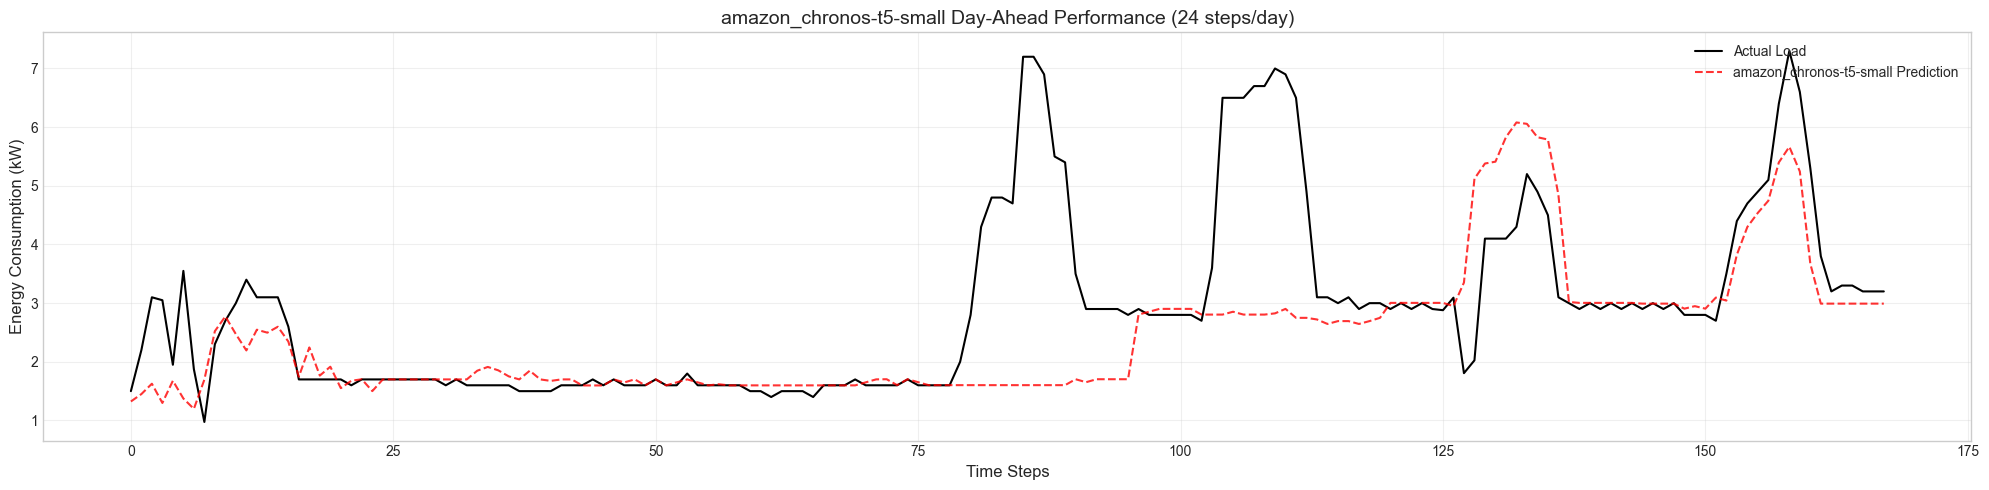

amazon_chronos-t5-small artifacts successfully saved to ../results/1_hour/amazon_chronos-t5-small/

Running amazon/chronos-t5-base

 RUNNING CHRONOS ZERO-SHOT (amazon_chronos-t5-base) | Horizon: 24
Cache found! Loading cached inferences from ../results/1_hour/amazon_chronos-t5-base\predictions.npz


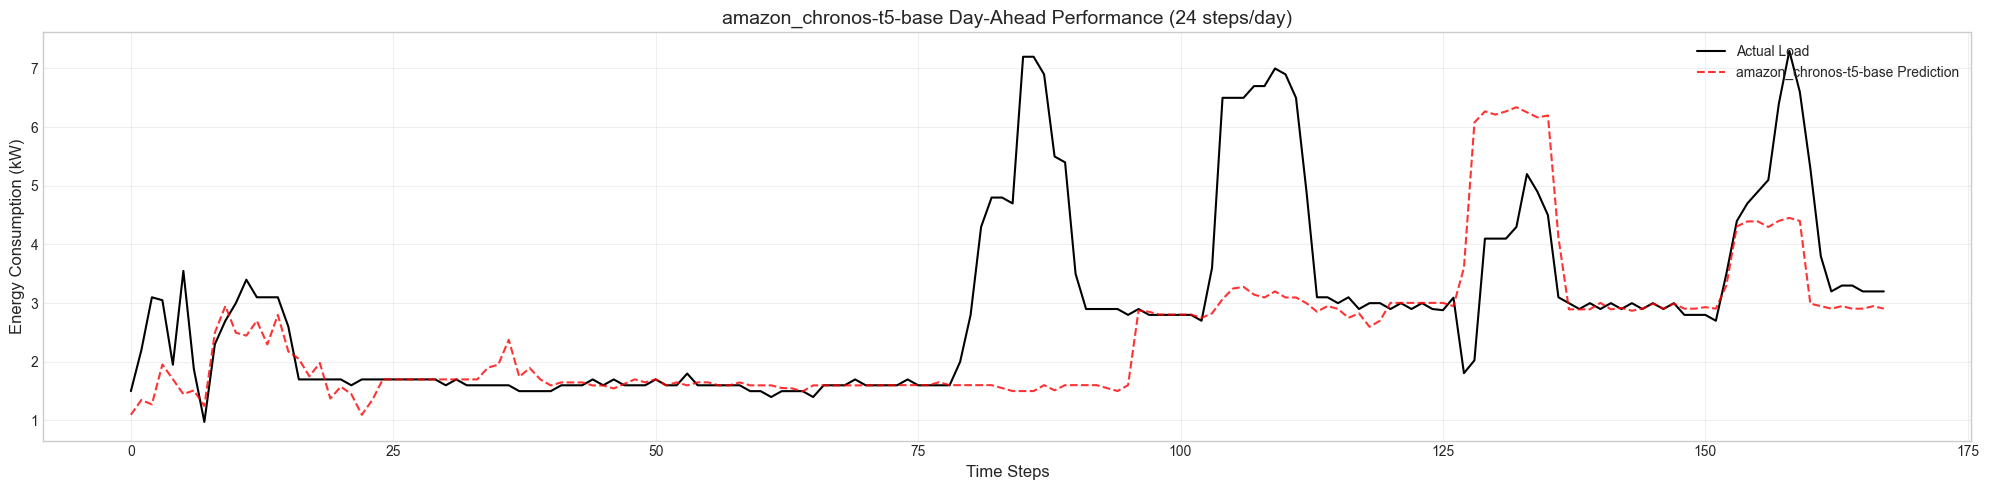

amazon_chronos-t5-base artifacts successfully saved to ../results/1_hour/amazon_chronos-t5-base/

Running amazon/chronos-t5-large

 RUNNING CHRONOS ZERO-SHOT (amazon_chronos-t5-large) | Horizon: 24
Cache found! Loading cached inferences from ../results/1_hour/amazon_chronos-t5-large\predictions.npz


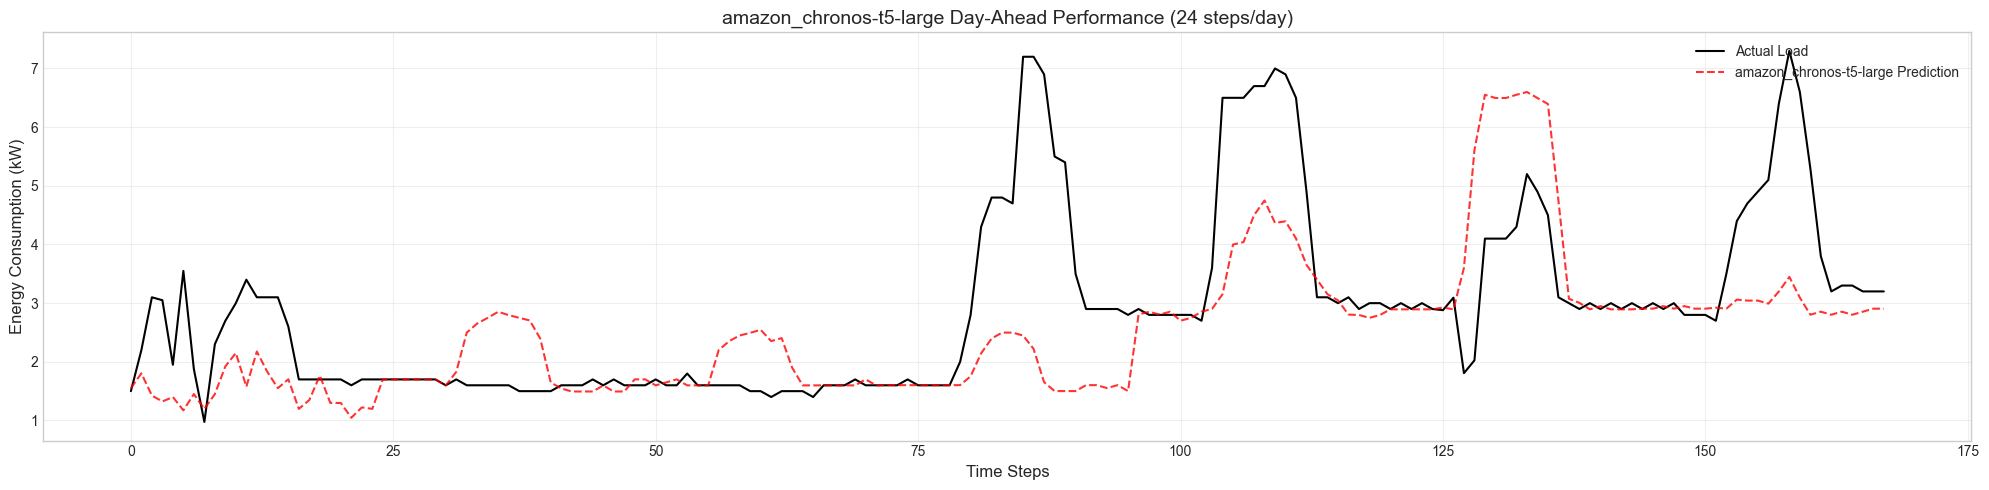

amazon_chronos-t5-large artifacts successfully saved to ../results/1_hour/amazon_chronos-t5-large/


In [10]:
chronos_models = [
    {"name": "amazon/chronos-t5-small", "batch_size": 32},
    {"name": "amazon/chronos-t5-base",  "batch_size": 16},
    {"name": config.CHRONOS_CONFIG["model_name"], "batch_size": config.CHRONOS_CONFIG["batch_size"]} 
]

for model_config in chronos_models:
    model_name = model_config["name"]
    batch_size = model_config["batch_size"]
    
    print(f"\nRunning {model_name}")
    
    results_chronos = run_chronos_univariate(
        df=df_master,
        target_col=TARGET_COL,
        horizon_name=HORIZON_NAME,
        model_name=model_name, 
        batch_size=batch_size, 
        context_length=256, # 10.6 days of context for 1-hour data
        train_from_scratch=TRAIN_FROM_SCRATCH
    )
    
    # Save artifacts using the existing pipeline
    save_experiment_results(
        results_dict=results_chronos, 
        model_name=results_chronos["model"], 
        horizon_name=HORIZON_NAME, 
        y_test=results_chronos['y_test_real'], 
        horizon=HORIZON_STEPS
    )
    
    # Metrics were already perfectly calculated inside the backend function!
    horizon_metrics.append(results_chronos["metrics"])

In [11]:
weather_cols = ["temperature_v1", "relative_humidity_v1", "wind_speed_v1", "clouds_v1"]
market_cols = ["energy_generation", "smp"]

time_cols = [
    "hour_sin", "hour_cos", "day_sin", "day_cos", "month_sin", "month_cos", 
    "is_holiday", "is_weekend", "is_non_working_day", "energy_flow_quarter"
]

lag_cols = [
    "energy_consumption_lag_1w", "energy_generation_lag_1w", 
    "smp_lag_1w", "temperature_v1_lag_1w"
]

df_oracle = df_master.copy()
df_degraded = df_master.copy()

total_rows = len(df_master)
train_val_idx = int(total_rows * (config.TRAIN_SPLIT + config.VAL_SPLIT))

np.random.seed(config.RANDOM_SEED)

for col in weather_cols + market_cols:
    if col == "temperature_v1":
        noise = np.random.normal(0.0, 2.0, size=(total_rows - train_val_idx)) 
    elif col in ["relative_humidity_v1", "clouds_v1"]:
        noise = np.random.normal(0.0, 5.0, size=(total_rows - train_val_idx)) 
    elif col == "wind_speed_v1":
        noise = np.random.normal(0.0, 1.5, size=(total_rows - train_val_idx)) 
    elif col in ["energy_generation", "smp"]:
        noise = np.random.normal(0.0, df_master[col].std() * 0.1, size=(total_rows - train_val_idx)) 
        
    df_degraded.iloc[train_val_idx:, df_degraded.columns.get_loc(col)] += noise


 RUNNING CHRONOS2_MULTIVARIATE_ORACLE | Horizon: 24
Loading cached inferences from ../results/1_hour/Chronos2_Multivariate_Oracle\predictions.npz
Chronos2_Multivariate_Oracle artifacts successfully saved to ../results/1_hour/Chronos2_Multivariate_Oracle/
Chronos2_Multivariate_Oracle added to leaderboard (MASE: 0.710)


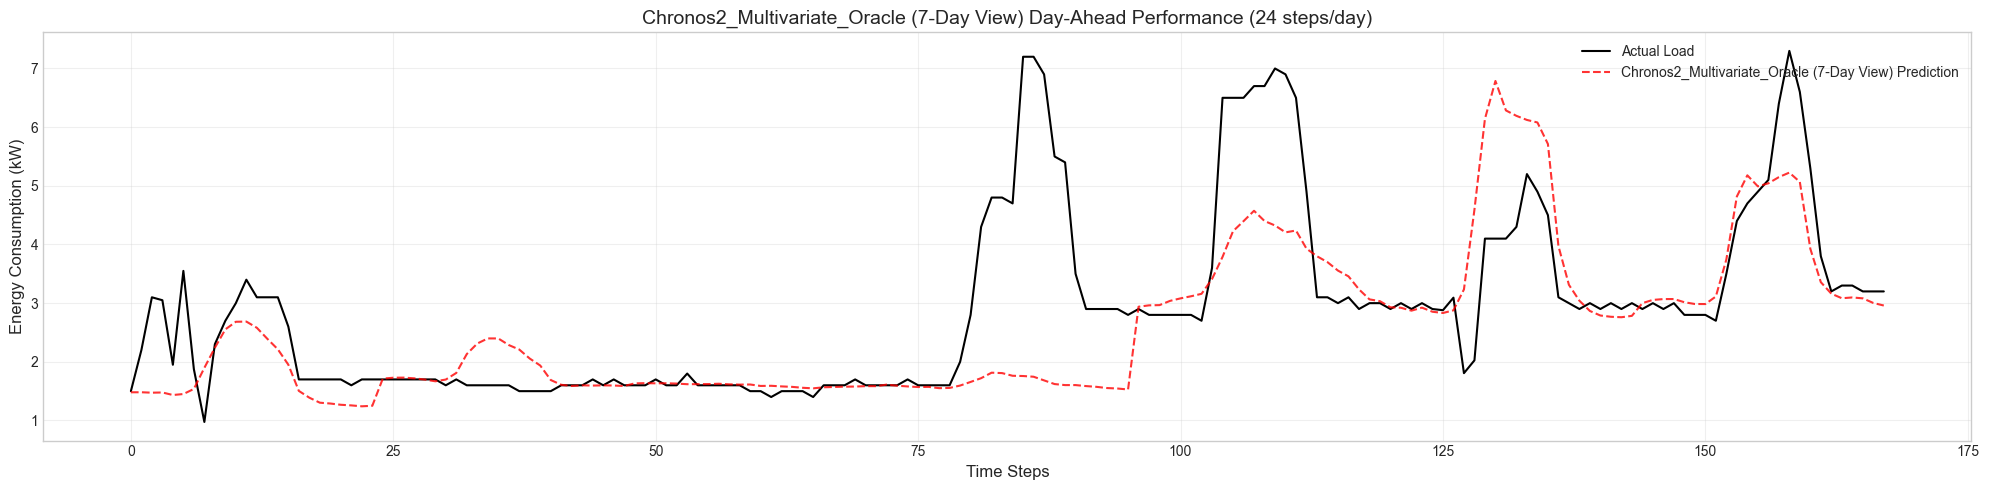


 RUNNING CHRONOS2_MULTIVARIATE_REALISTIC | Horizon: 24
Loading cached inferences from ../results/1_hour/Chronos2_Multivariate_Realistic\predictions.npz
Chronos2_Multivariate_Realistic artifacts successfully saved to ../results/1_hour/Chronos2_Multivariate_Realistic/
Chronos2_Multivariate_Realistic added to leaderboard (MASE: 0.713)


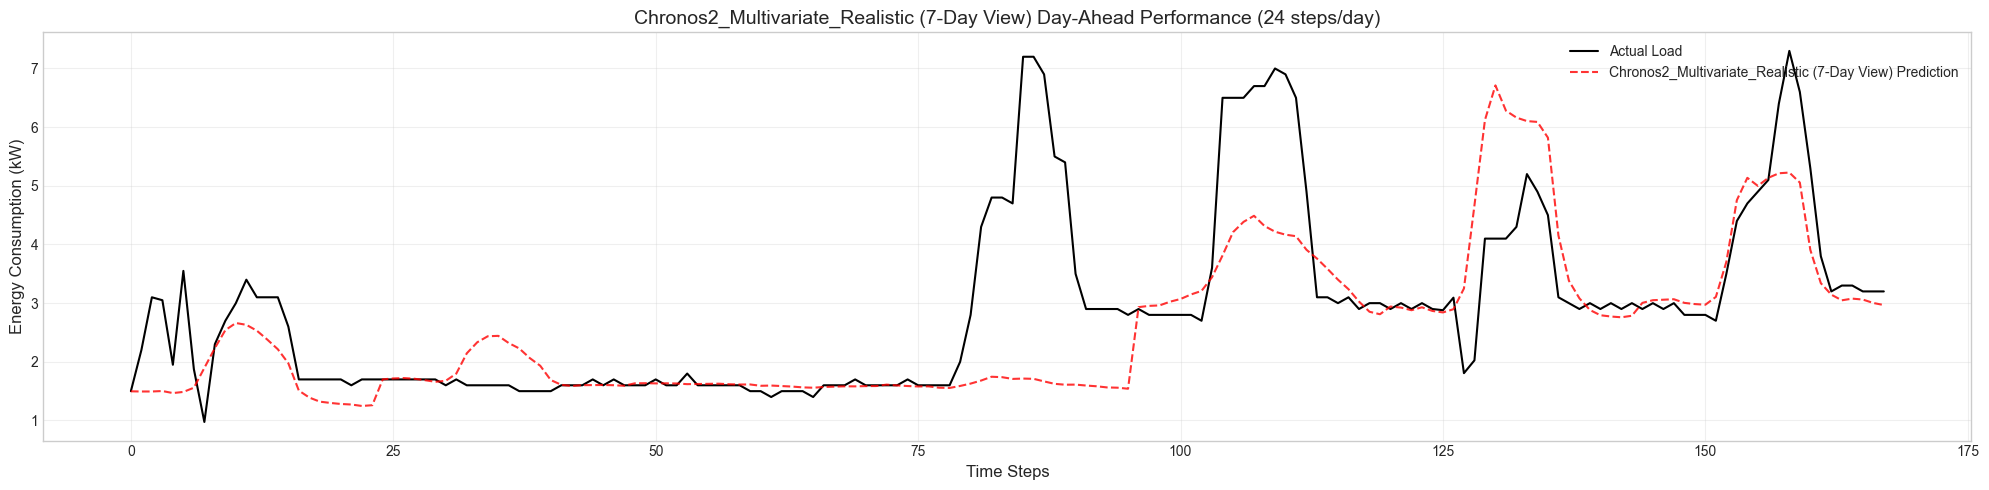


 RUNNING CHRONOS2_MULTIVARIATE_BLIND | Horizon: 24
Loading cached inferences from ../results/1_hour/Chronos2_Multivariate_Blind\predictions.npz
Chronos2_Multivariate_Blind artifacts successfully saved to ../results/1_hour/Chronos2_Multivariate_Blind/
Chronos2_Multivariate_Blind added to leaderboard (MASE: 0.705)


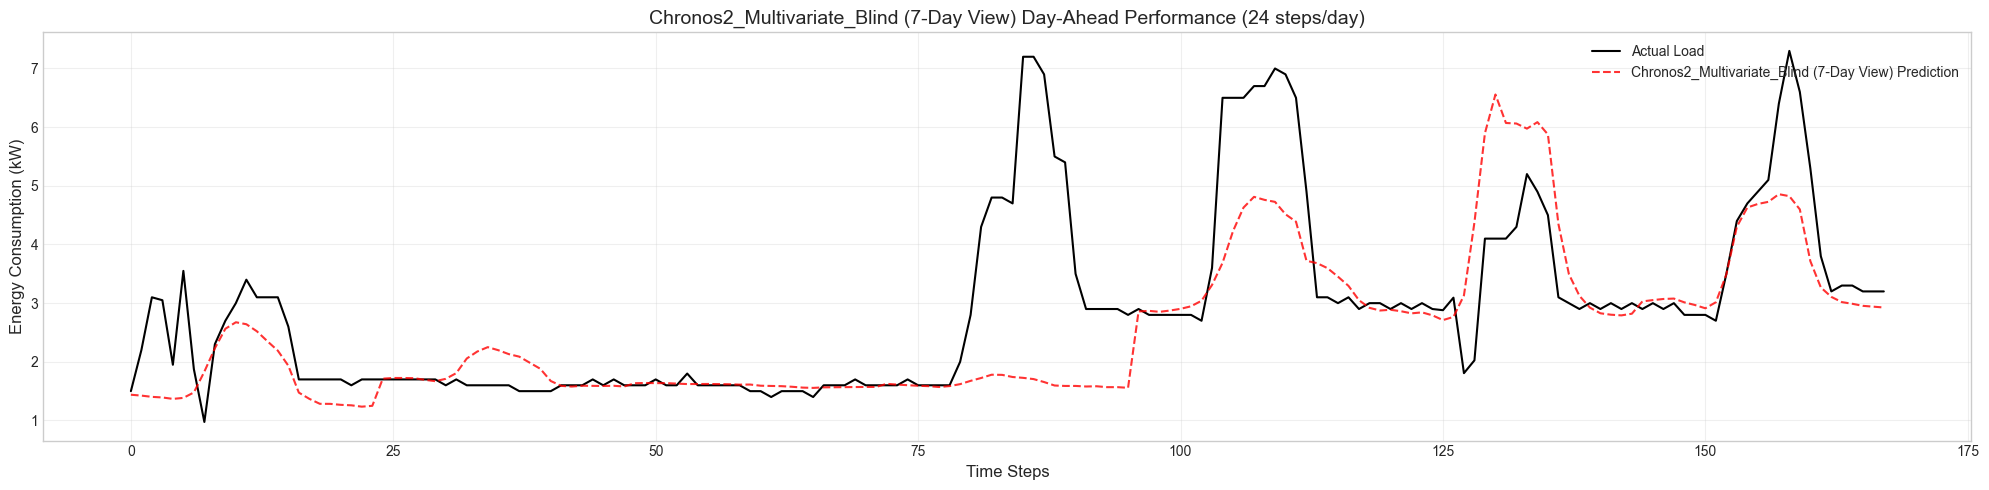

In [12]:
base_deterministic_cols = time_cols + lag_cols
uncertain_forecast_cols = weather_cols + market_cols

chronos2_experiments = [
    {
        "exp_name": "Chronos2_Multivariate_Oracle",
        "df": df_oracle,
        "covariates": base_deterministic_cols + uncertain_forecast_cols 
    },
    {
        "exp_name": "Chronos2_Multivariate_Realistic",
        "df": df_degraded,
        "covariates": base_deterministic_cols + uncertain_forecast_cols
    },
    {
        "exp_name": "Chronos2_Multivariate_Blind",
        "df": df_master,
        "covariates": base_deterministic_cols 
    }
]

# Extract pure 1D raw history once before the loop
y_train_raw = df_master[TARGET_COL].values[:int(len(df_master) * (config.TRAIN_SPLIT + config.VAL_SPLIT))]

for exp in chronos2_experiments:
    results = run_chronos2_multivariate_v2(
        df=exp["df"],
        deterministic_covariates=exp["covariates"],
        experiment_name=exp["exp_name"],
        target_col=TARGET_COL,
        horizon_name=HORIZON_NAME,
        model_name=config.CHRONOS_2_CONFIG["model_name"],
        batch_size=config.CHRONOS_2_CONFIG["batch_size"],
        context_length=256, # 10.6 days of context for 1-hour data
        train_from_scratch=TRAIN_FROM_SCRATCH
    )
    
    # Explicitly calculating metrics for the leaderboard
    metrics = calculate_metrics(
        y_true=results['y_test_real'], 
        y_pred=results['predictions'], 
        model_name=exp['exp_name'], 
        execution_time=results['execution_time'], 
        horizon=HORIZON_STEPS, 
        y_train=y_train_raw
    )
    results['metrics'] = metrics
    
    save_experiment_results(
        results_dict=results, 
        model_name=exp['exp_name'], 
        horizon_name=HORIZON_NAME, 
        y_test=results['y_test_real'], 
        horizon=HORIZON_STEPS
    )
    
    horizon_metrics.append(metrics)
    print(f"{exp['exp_name']} added to leaderboard (MASE: {metrics['MASE']:.3f})")
    
    plot_predictions(
        y_true=results['y_test_real'], 
        y_pred=results['predictions'], 
        model_name=f"{exp['exp_name']} (7-Day View)", 
        horizon=HORIZON_STEPS,
        num_steps=HORIZON_STEPS * 7 
    )

# Final Evaluation & Statistical Diagnostics

This final execution block consolidates the complete evaluation pipeline for this temporal horizon. It moves beyond standard point-forecast metrics to rigorously test the models for statistical significance, physical explainability, and econometric stability. 

The pipeline executes the following five evaluations:

### 1. Global Performance Metrics & Hourly Error Heatmap
* **The Leaderboard:** Compiles the final evaluation metrics (MASE, RMSE, MAE, sMAPE) and sorts the models to identify the absolute champion.
* **The Heatmap:** Generates a cross-model chronological heatmap to visually identify specific hours or days where models systematically succeed or fail.

### 2. Feature Importance (Explainability)
* **The Goal:** Opens the "black box" of the classical Machine Learning algorithms (XGBoost & Random Forest).
* **The Output:** Bar charts extracting the top 15 features, proving whether the models rely more heavily on autoregressive momentum (lags), cyclical human behavior (calendar features), or exogenous weather data.

### 3. Probabilistic Forecasts (Uncertainty Bounds)
* **The Goal:** To evaluate the champion models' capacity for operational risk management.
* **The Output:** Visualizes the median prediction (P50) alongside the 10th and 90th percentile bounds (an 80% confidence interval). This demonstrates how the model dynamically widens its uncertainty during highly volatile daytime grid operations.

### 4. Residual Diagnostics (Econometric "White-Noise" Testing)
* **The Goal:** A perfect forecasting model should leave behind errors that are completely random (white noise). This phase tests the champion model's errors for uncaptured patterns.
* **The Output:** * **Shapiro-Wilk Test & Distribution:** Tests the residuals for normality and leptokurtosis (heavy tails).
    * **ACF & PACF Plots:** The "Memory" test. Identifies whether the errors are correlated with each other, exposing any uncaptured deterministic seasonality (e.g., a lingering 24-hour diurnal cycle).

### 5. Diebold-Mariano Statistical Significance Shootout
* **The Goal:** To prove that the champion model's superiority is mathematically definitive, not a product of random chance.
* **The Output:** A pairwise statistical matrix comparing the champion model against every other baseline and contender ($a = 0.05$).


 EVALUATION METRICS TABLE FOR (1_hour)
Leaderboard successfully saved to ../results/1_hour/leaderboard.csv


,Model,RMSE,MAE,R2,CVRMSE,NMBE,sMAPE,MASE,Time (s)
0,amazon_chronos-t5-large,0.9969,0.5436,0.7508,0.3608,0.0233,17.0836,0.6865,883.36 s
1,Chronos2_Multivariate_Blind,0.9956,0.5578,0.7514,0.3603,0.0091,17.9757,0.7045,59.92 s
2,Chronos2_Multivariate_Oracle,1.0028,0.5623,0.7478,0.3630,0.0112,18.1662,0.7102,64.14 s
3,Chronos2_Multivariate_Realistic,1.0064,0.5647,0.7460,0.3643,0.0119,18.1933,0.7132,60.80 s
4,amazon_chronos-t5-base,1.0911,0.5820,0.7014,0.3949,0.0352,18.1133,0.7350,163.74 s
5,Vanilla_Transformer_1Day_Context,1.0330,0.6869,0.7342,0.3728,-0.0040,24.4707,0.8024,57.64 s
6,amazon_chronos-t5-small,1.2274,0.6440,0.6222,0.4442,0.0381,19.8304,0.8134,53.17 s
7,Random_Forest,1.0901,0.7035,0.7040,0.3934,0.0483,24.6049,0.8218,0.29 s
8,XGBoost_RMSE,1.0967,0.7162,0.7004,0.3958,0.0820,24.9911,0.8366,0.18 s
9,PatchTST_1Day_2Hr_Patches,1.3205,0.7250,0.5657,0.4766,0.0641,22.3004,0.8468,1159.50 s



 HEATMAP

 Generating Master Hourly Error Heatmap


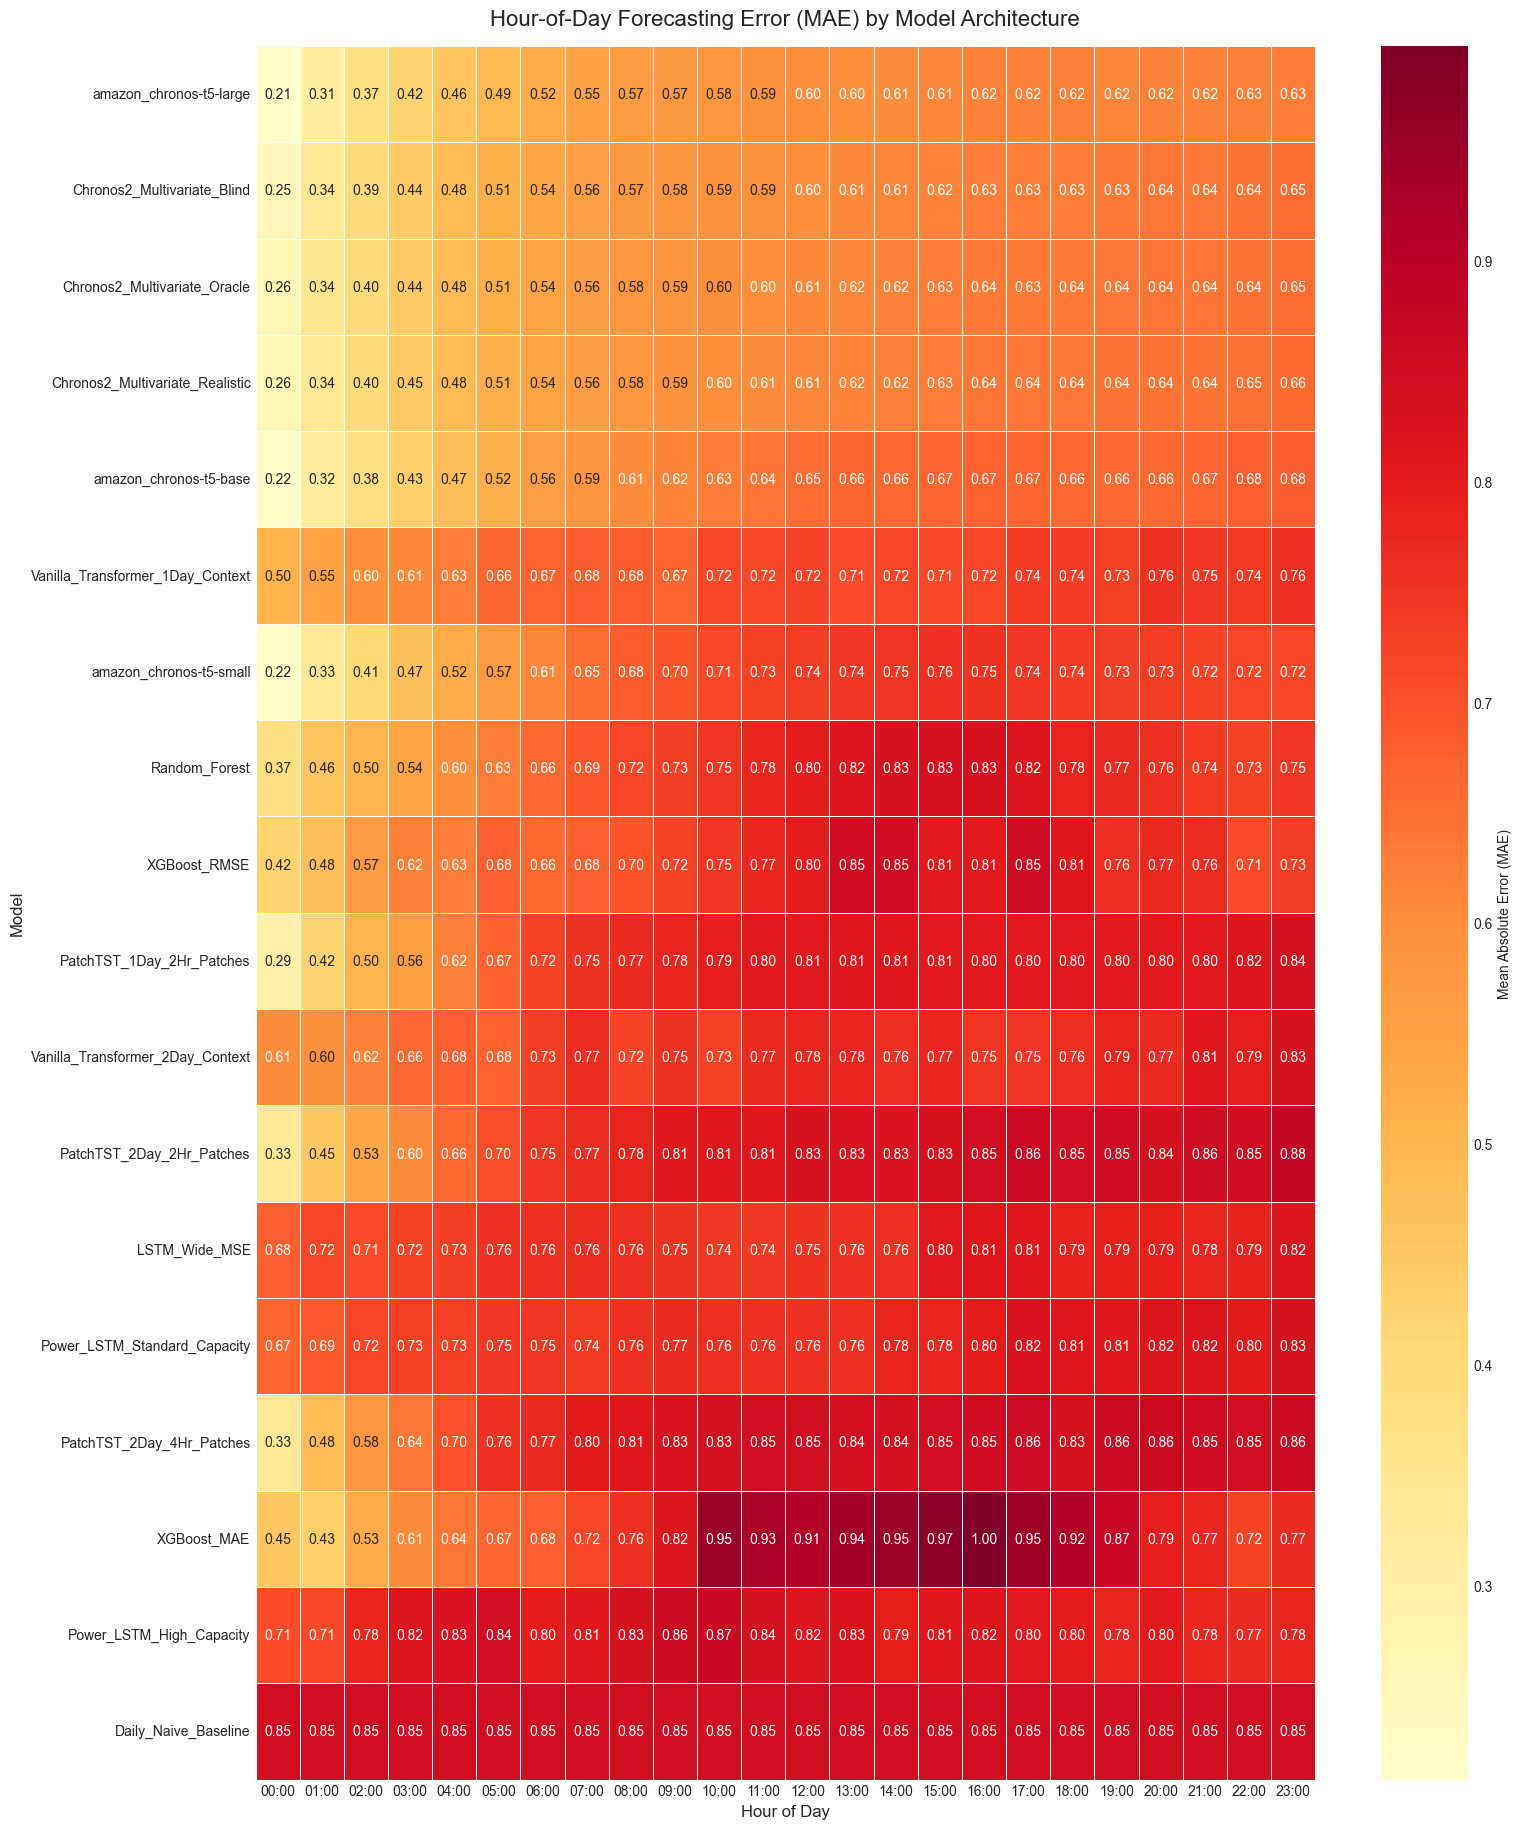


 TREE FEATURE IMPORTANCE:


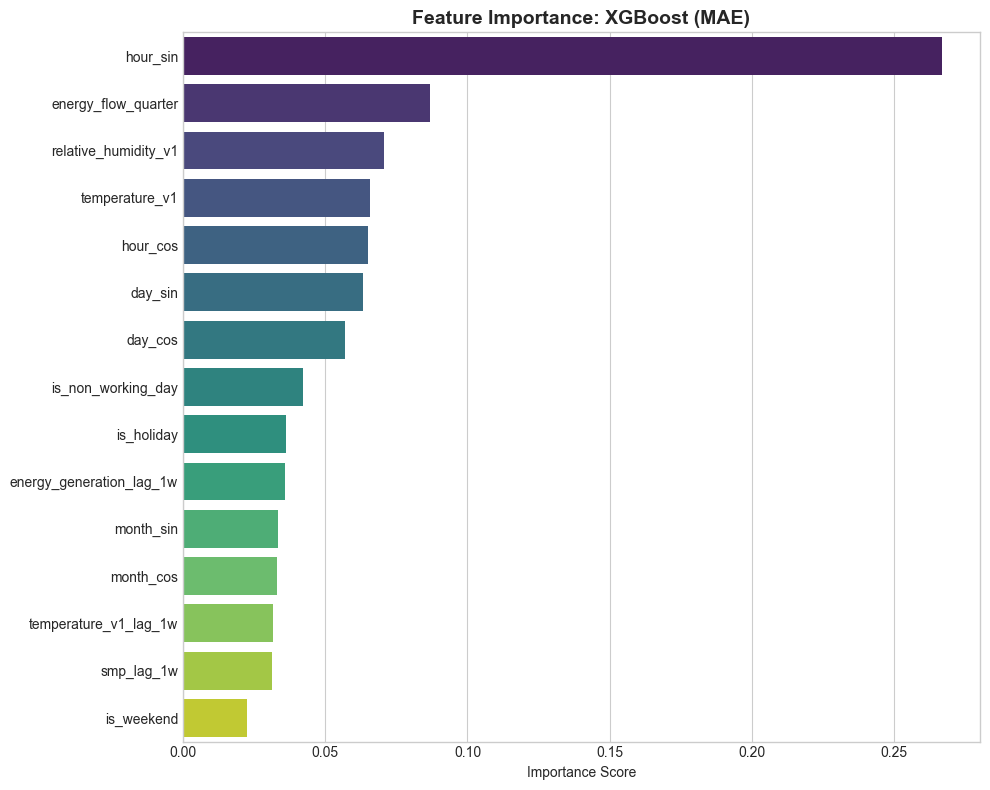

,Feature,Importance
0,hour_sin,0.266808
1,energy_flow_quarter,0.086974
2,relative_humidity_v1,0.070726
3,temperature_v1,0.065858
4,hour_cos,0.064927
5,day_sin,0.063391
6,day_cos,0.056820
7,is_non_working_day,0.042234
8,is_holiday,0.036270
9,energy_generation_lag_1w,0.035889


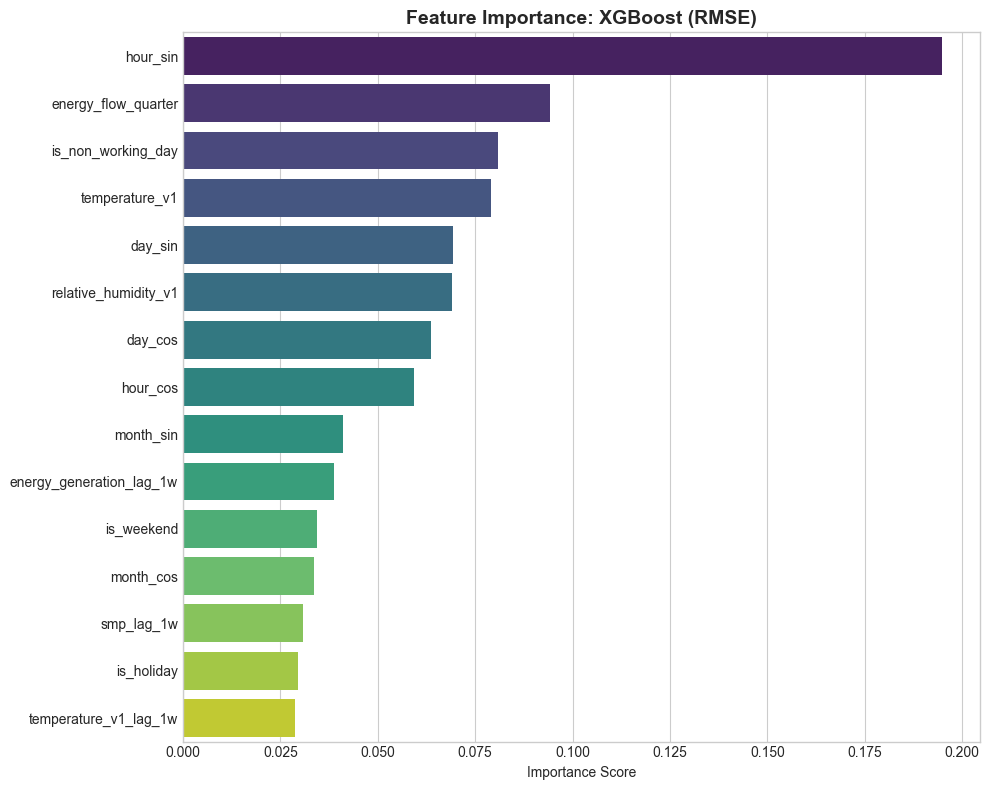

,Feature,Importance
0,hour_sin,0.194790
1,energy_flow_quarter,0.094205
2,is_non_working_day,0.080785
3,temperature_v1,0.079096
4,day_sin,0.069265
5,relative_humidity_v1,0.069134
6,day_cos,0.063750
7,hour_cos,0.059355
8,month_sin,0.041185
9,energy_generation_lag_1w,0.038783


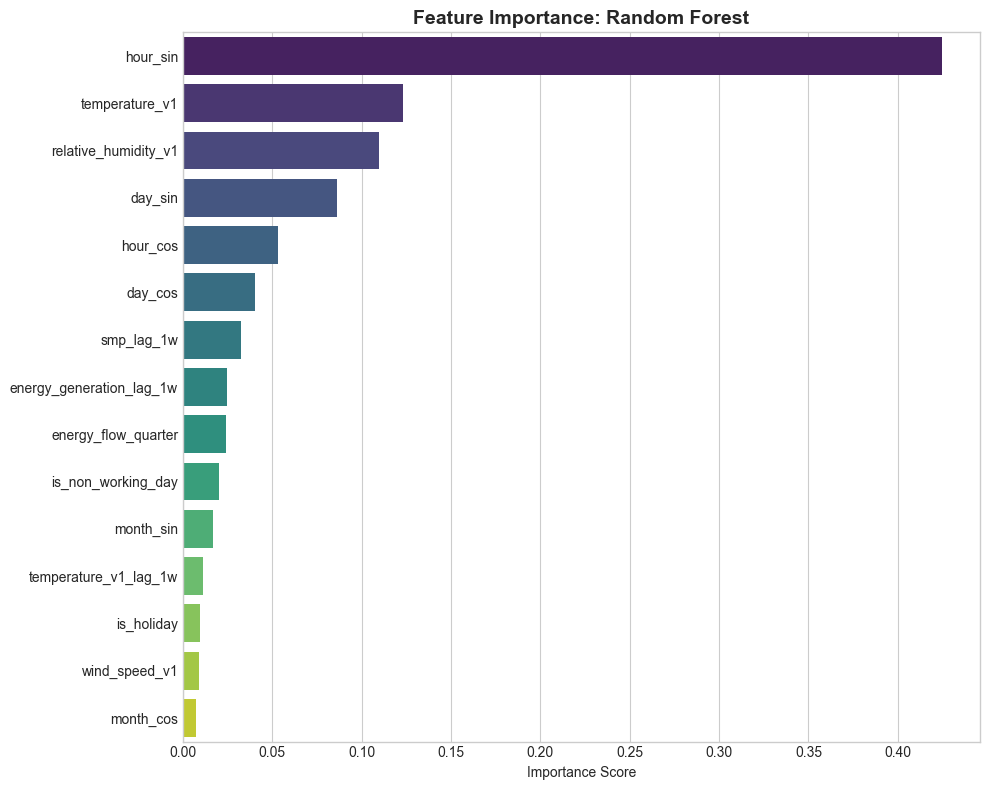

,Feature,Importance
0,hour_sin,0.424798
1,temperature_v1,0.123049
2,relative_humidity_v1,0.109923
3,day_sin,0.086235
4,hour_cos,0.053355
5,day_cos,0.040024
6,smp_lag_1w,0.032574
7,energy_generation_lag_1w,0.024436
8,energy_flow_quarter,0.023835
9,is_non_working_day,0.020410



 PROBABILISTIC FORECASTS:


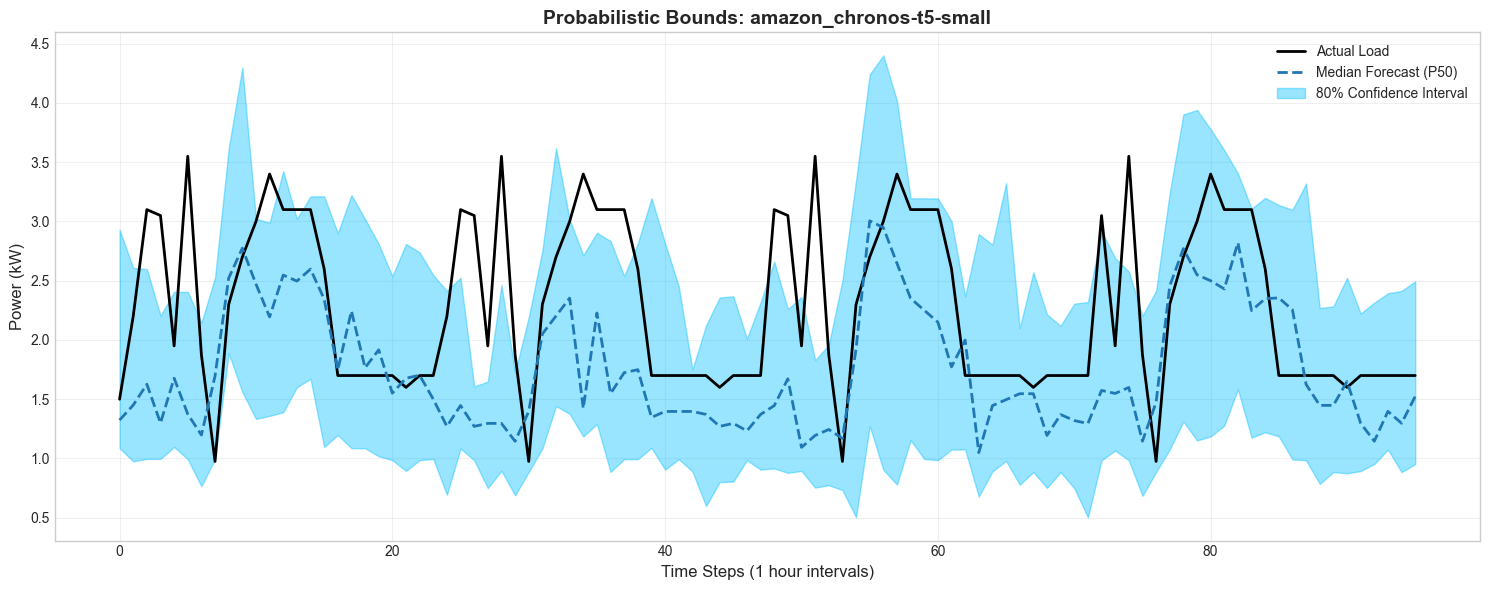

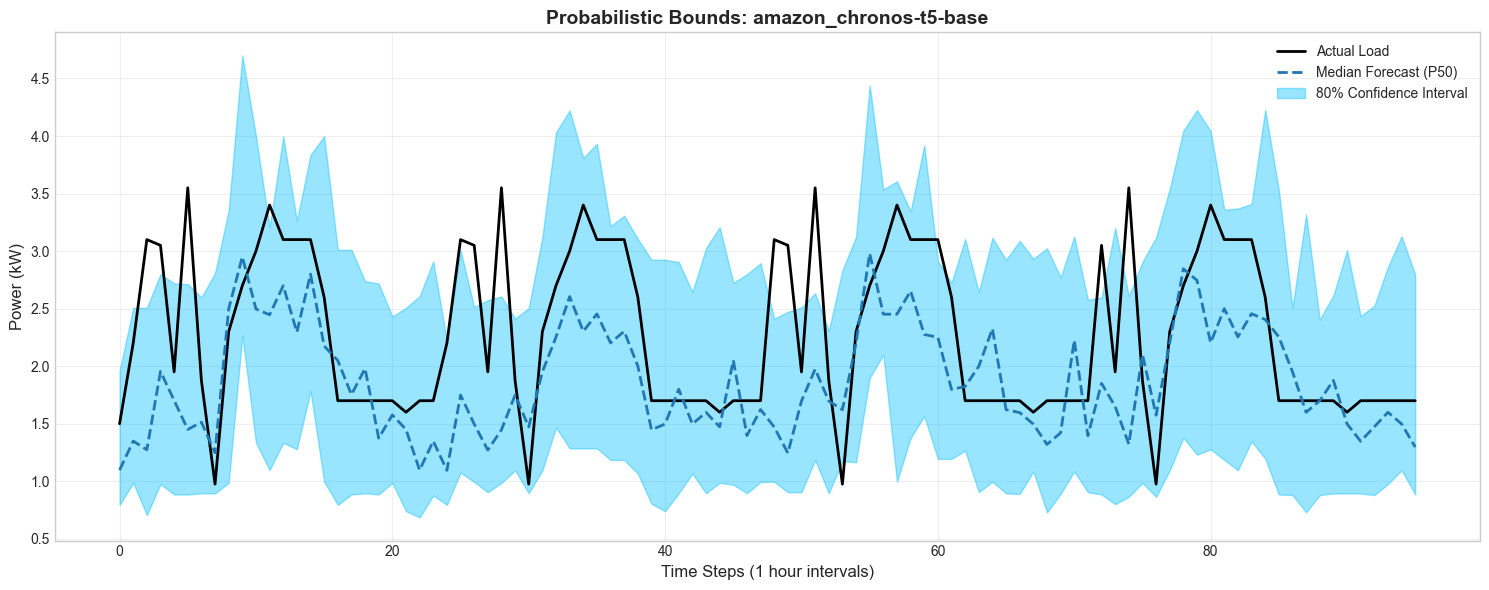

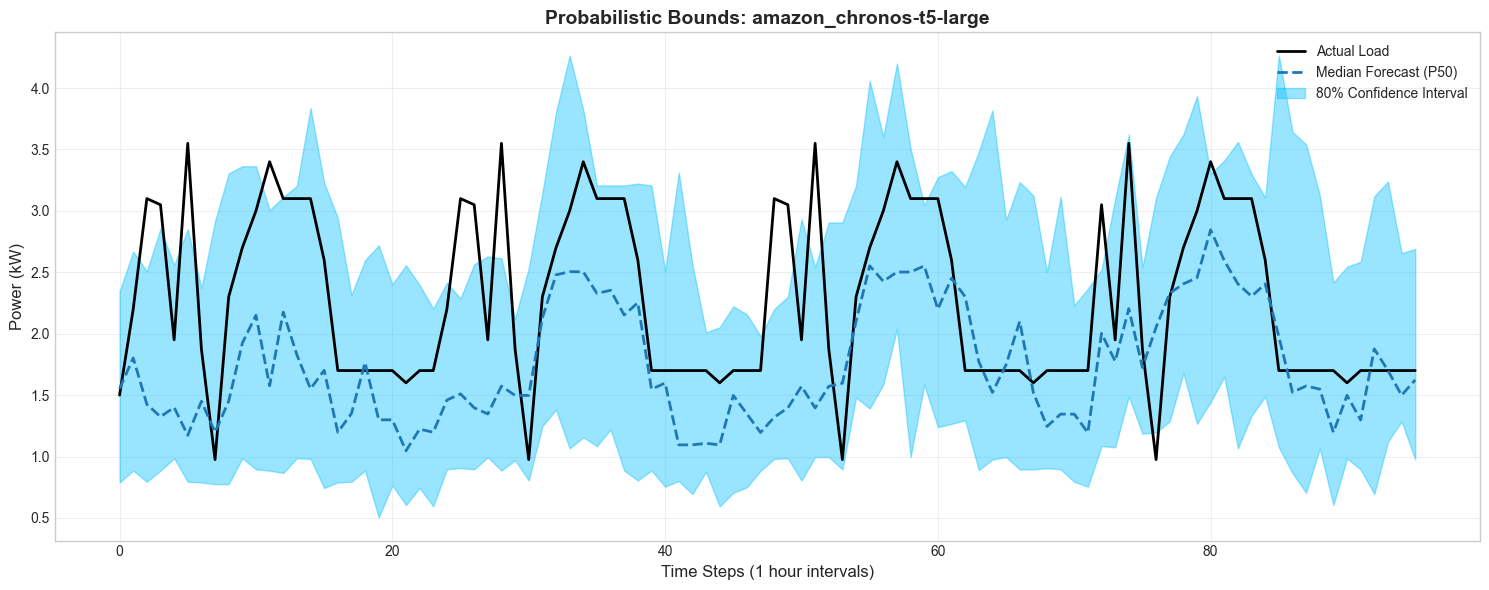

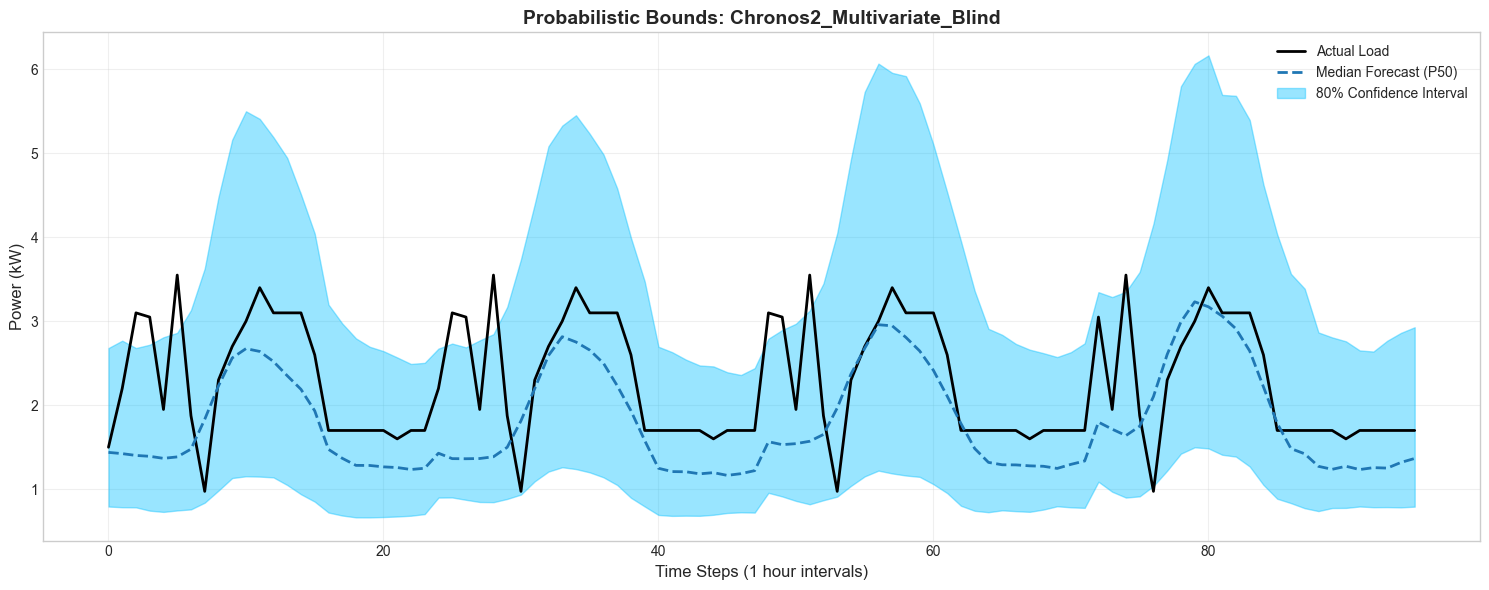

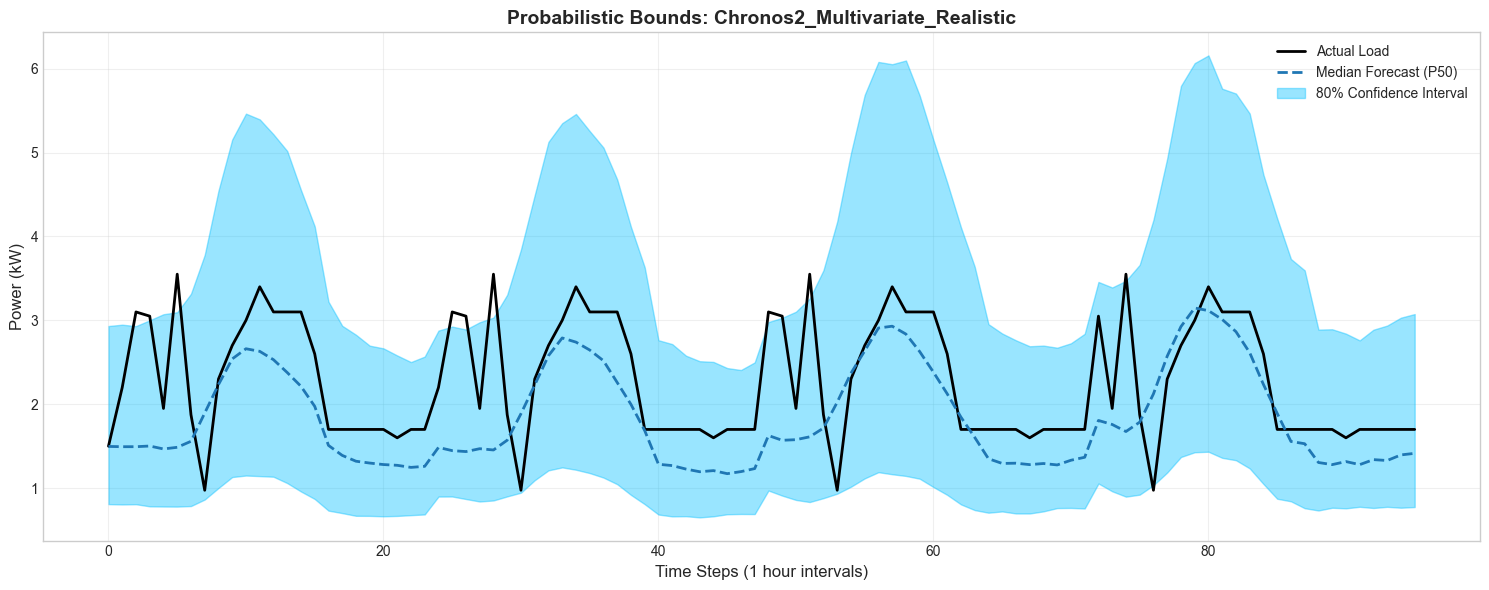

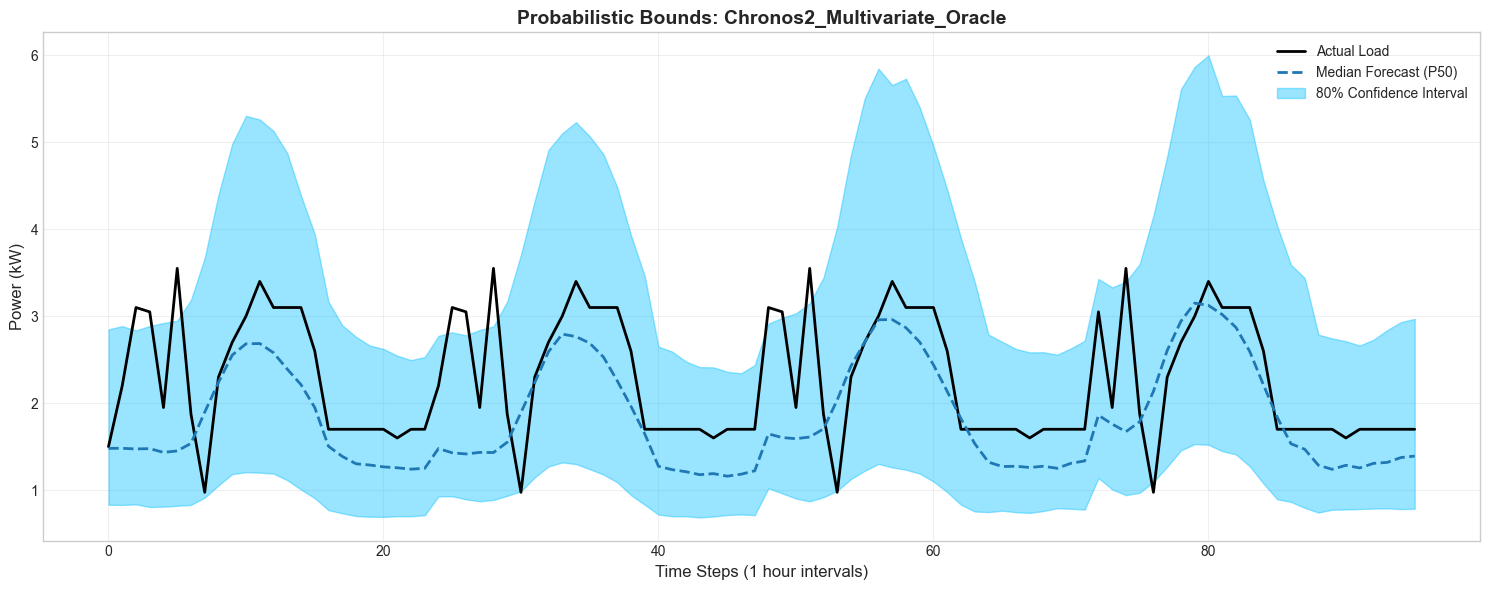


 RESIDUAL DIAGNOSTICS: amazon_chronos-t5-large
Systematic Bias (Mean Error): 0.0643
Shapiro-Wilk Normality p-value: 0.0000e+00


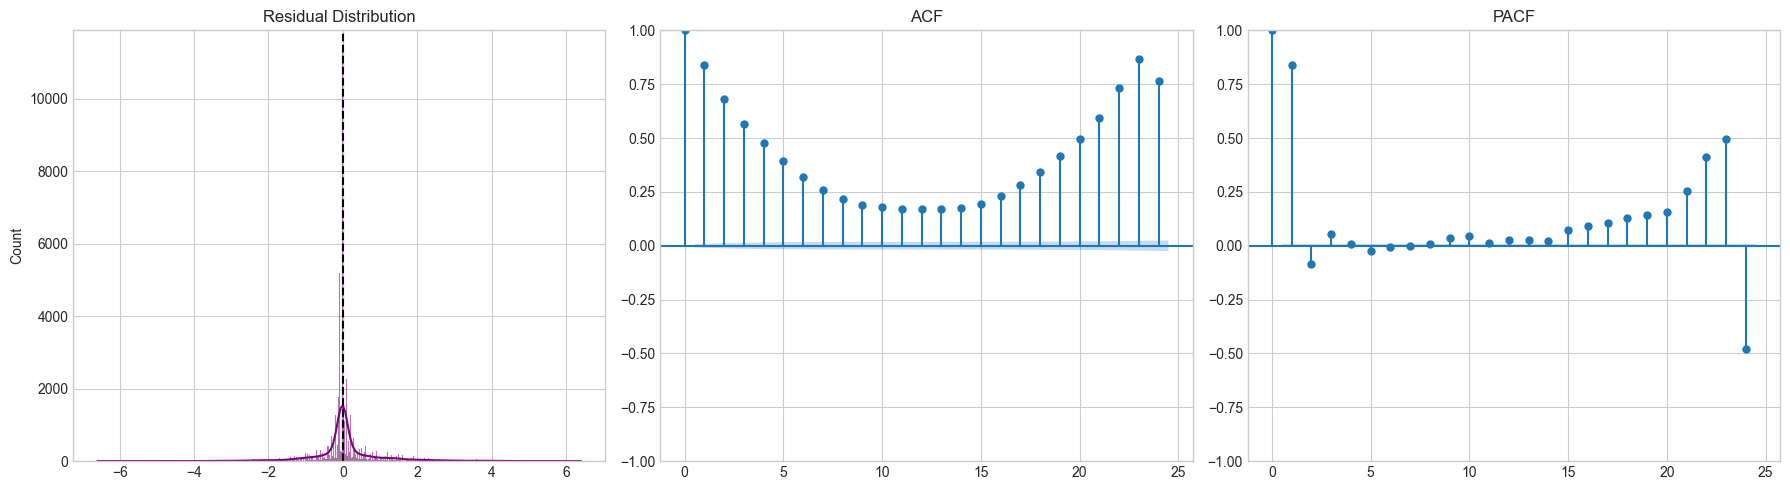


ALIGNING ARRAYS & EXECUTING DIEBOLD-MARIANO

Statistical Significance Testing
Reference Model: amazon_chronos-t5-large


,Evaluated_Model,DM_Statistic,Raw_p_value,Corrected_p_value,Statistically_Significant,Superior_Model
8,PatchTST_1Day_2Hr_Patches,-12.654978,0.000000e+00,0.000000e+00,True,amazon_chronos-t5-large
14,XGBoost_MAE,-18.308054,0.000000e+00,0.000000e+00,True,amazon_chronos-t5-large
13,PatchTST_2Day_4Hr_Patches,-16.378120,0.000000e+00,0.000000e+00,True,amazon_chronos-t5-large
12,Power_LSTM_Standard_Capacity,-16.405850,0.000000e+00,0.000000e+00,True,amazon_chronos-t5-large
11,LSTM_Wide_MSE,-17.335349,0.000000e+00,0.000000e+00,True,amazon_chronos-t5-large
10,PatchTST_2Day_2Hr_Patches,-14.864782,0.000000e+00,0.000000e+00,True,amazon_chronos-t5-large
9,Vanilla_Transformer_2Day_Context,-15.832337,0.000000e+00,0.000000e+00,True,amazon_chronos-t5-large
15,Power_LSTM_High_Capacity,-17.517541,0.000000e+00,0.000000e+00,True,amazon_chronos-t5-large
16,Daily_Naive_Baseline,-16.171381,0.000000e+00,0.000000e+00,True,amazon_chronos-t5-large
6,Random_Forest,-13.686439,0.000000e+00,0.000000e+00,True,amazon_chronos-t5-large


,Evaluated_Model,DM_Statistic,Raw_p_value,Corrected_p_value,Statistically_Significant,Superior_Model
8,PatchTST_1Day_2Hr_Patches,-12.654978,0.000000e+00,0.000000e+00,True,amazon_chronos-t5-large
14,XGBoost_MAE,-18.308054,0.000000e+00,0.000000e+00,True,amazon_chronos-t5-large
13,PatchTST_2Day_4Hr_Patches,-16.378120,0.000000e+00,0.000000e+00,True,amazon_chronos-t5-large
12,Power_LSTM_Standard_Capacity,-16.405850,0.000000e+00,0.000000e+00,True,amazon_chronos-t5-large
11,LSTM_Wide_MSE,-17.335349,0.000000e+00,0.000000e+00,True,amazon_chronos-t5-large
10,PatchTST_2Day_2Hr_Patches,-14.864782,0.000000e+00,0.000000e+00,True,amazon_chronos-t5-large
9,Vanilla_Transformer_2Day_Context,-15.832337,0.000000e+00,0.000000e+00,True,amazon_chronos-t5-large
15,Power_LSTM_High_Capacity,-17.517541,0.000000e+00,0.000000e+00,True,amazon_chronos-t5-large
16,Daily_Naive_Baseline,-16.171381,0.000000e+00,0.000000e+00,True,amazon_chronos-t5-large
6,Random_Forest,-13.686439,0.000000e+00,0.000000e+00,True,amazon_chronos-t5-large


In [13]:
# LEADERBOARD COMPILATION

print(f"\n EVALUATION METRICS TABLE FOR ({HORIZON_NAME})")
results_df = pd.DataFrame(horizon_metrics)

if 'Model' in results_df.columns:
    results_df = results_df.drop_duplicates(subset=['Model'], keep='last')
if 'MASE' in results_df.columns:
    results_df = results_df.sort_values(by="MASE").reset_index(drop=True)

save_path = f"../results/{HORIZON_NAME}/leaderboard.csv"
results_df.to_csv(save_path, index=False)
print(f"Leaderboard successfully saved to {save_path}")

display_df = results_df.copy()
time_col = next((col for col in display_df.columns if "Time" in col or "time" in col.lower()), None)
numeric_cols = display_df.select_dtypes(include=['float64', 'float32']).columns

for col in numeric_cols:
    if col != time_col: display_df[col] = display_df[col].apply(lambda x: f"{x:.4f}")
if time_col and display_df[time_col].dtype in ['float64', 'float32']:
    display_df[time_col] = display_df[time_col].apply(lambda x: f"{x:.2f} s")

display(display_df)


# CACHE LOADER

model_results_dict = {}

for model_name in results_df["Model"]:
    cache_path_npz = f"../results/{HORIZON_NAME}/{model_name}/predictions.npz"
    
    # A. Deep Learning & Chronos (.npz)
    if os.path.exists(cache_path_npz):
        loaded = np.load(cache_path_npz)
        model_data = {'y_test_real': loaded['y_test_real'], 'predictions': loaded['predictions']}
        if 'lower_bounds' in loaded:
            model_data['lower_bounds'] = loaded['lower_bounds']
            model_data['upper_bounds'] = loaded['upper_bounds']
        model_results_dict[model_name] = model_data
        
    # B. Tree Models (.joblib via on-the-fly prediction)
    elif "XGBoost" in model_name or "Random_Forest" in model_name:
        if "MAE" in model_name: joblib_path = f"../results/{HORIZON_NAME}/{model_name}/xgboost_mae_model.joblib"
        elif "RMSE" in model_name: joblib_path = f"../results/{HORIZON_NAME}/{model_name}/xgboost_rmse_model.joblib"
        else: joblib_path = f"../results/{HORIZON_NAME}/{model_name}/random_forest_model.joblib"
            
        if os.path.exists(joblib_path):
            cached_model = joblib.load(joblib_path)
            test_preds = cached_model.predict(X_test_tree)
            orig_shape = test_preds.shape
            test_preds_unscaled = dl_scaler_targ.inverse_transform(test_preds.reshape(-1, 1)).reshape(orig_shape)
            model_results_dict[model_name] = {'y_test_real': y_test_unscaled, 'predictions': test_preds_unscaled}
            
    # C. Daily Naive (Mathematical Shift)
    elif "Naive" in model_name:
        naive_preds = run_daily_naive(y_test_unscaled, horizon=HORIZON_STEPS)
        model_results_dict[model_name] = {'y_test_real': y_test_unscaled, 'predictions': naive_preds}


# THE HEATMAP

print("\n HEATMAP")
if model_results_dict:
    master_error_df = plot_hourly_error_heatmap(model_results_dict)


# DEFINE STATISTICAL FUNCTIONS

def plot_probabilistic_forecast(y_true, y_pred_median, lower_bound, upper_bound, model_name, days_to_plot=4):
    horizon_steps = config.HORIZON_STEPS[config.ACTIVE_HORIZON]
    num_steps = horizon_steps * days_to_plot
    plt.figure(figsize=(15, 6))
    x_axis = np.arange(num_steps)
    
    plt.plot(x_axis, y_true.flatten()[:num_steps], label="Actual Load", color="black", linewidth=2)
    plt.plot(x_axis, y_pred_median.flatten()[:num_steps], label="Median Forecast (P50)", color="#1f77b4", linestyle="--", linewidth=2)
    plt.fill_between(x_axis, lower_bound.flatten()[:num_steps], upper_bound.flatten()[:num_steps], color='#00BFFF', alpha=0.4, label="80% Confidence Interval")
    
    plt.title(f"Probabilistic Bounds: {model_name}", fontsize=14, fontweight='bold')
    plt.xlabel(f"Time Steps ({config.ACTIVE_HORIZON.replace('_', ' ')} intervals)", fontsize=12)
    plt.ylabel("Power (kW)", fontsize=12)
    plt.legend(loc="upper right")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_tree_feature_importance(trained_model, feature_names, top_n=15, model_title="XGBoost"):
    if hasattr(trained_model, 'estimators_'): importances = np.mean([e.feature_importances_ for e in trained_model.estimators_], axis=0)
    elif hasattr(trained_model, 'feature_importances_'): importances = trained_model.feature_importances_
    
    indices = np.argsort(importances)[::-1][:top_n]
    top_features, top_importances = [feature_names[i] for i in indices], importances[indices]
    
    plt.figure(figsize=(10, 8))
    sns.barplot(x=top_importances, y=top_features, palette="viridis")
    plt.title(f"Feature Importance: {model_title}", fontsize=14, fontweight='bold')
    plt.xlabel("Importance Score")
    plt.tight_layout()
    plt.show()
    return pd.DataFrame({"Feature": top_features, "Importance": top_importances})

def analyze_residuals(y_true, y_pred, model_name, lags):
    residuals = y_true.flatten() - y_pred.flatten()
    print(f"\n RESIDUAL DIAGNOSTICS: {model_name}")
    print(f"Systematic Bias (Mean Error): {np.mean(residuals):.4f}")
    
    stat, p_value = stats.shapiro(np.random.choice(residuals, min(4000, len(residuals)), replace=False))
    print(f"Shapiro-Wilk Normality p-value: {p_value:.4e}")
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    sns.histplot(residuals, kde=True, ax=axes[0], color='purple').set_title("Residual Distribution")
    axes[0].axvline(0, color='black', linestyle='--')
    sm.graphics.tsa.plot_acf(residuals, lags=lags, ax=axes[1], title="ACF")
    sm.graphics.tsa.plot_pacf(residuals, lags=lags, ax=axes[2], title="PACF")
    plt.tight_layout()
    plt.show()


# TREE FEATURES & PROBABILISTICS

print("\n TREE FEATURE IMPORTANCE:")
tree_feature_names = ["hour_sin", "hour_cos", "day_sin", "day_cos", "month_sin", "month_cos", "is_holiday", "is_weekend", "is_non_working_day", "energy_flow_quarter", "temperature_v1", "relative_humidity_v1", "wind_speed_v1", "clouds_v1", "energy_consumption_lag_1w", "energy_generation_lag_1w", "smp_lag_1w", "temperature_v1_lag_1w"]

for m in [{"folder": "XGBoost_MAE", "file": "xgboost_mae_model.joblib", "title": "XGBoost (MAE)"}, {"folder": "XGBoost_RMSE", "file": "xgboost_rmse_model.joblib", "title": "XGBoost (RMSE)"}, {"folder": "Random_Forest", "file": "random_forest_model.joblib", "title": "Random Forest"}]:
    try: display(plot_tree_feature_importance(joblib.load(f"../results/{HORIZON_NAME}/{m['folder']}/{m['file']}"), tree_feature_names, 15, m["title"]))
    except: pass

print("\n PROBABILISTIC FORECASTS:")
for m in ["amazon_chronos-t5-small", "amazon_chronos-t5-base", "amazon_chronos-t5-large", "Chronos2_Multivariate_Blind", "Chronos2_Multivariate_Realistic", "Chronos2_Multivariate_Oracle"]:
    if m in model_results_dict and 'lower_bounds' in model_results_dict[m]:
        plot_probabilistic_forecast(model_results_dict[m]['y_test_real'], model_results_dict[m]['predictions'], model_results_dict[m]['lower_bounds'], model_results_dict[m]['upper_bounds'], m)


# DIAGNOSTICS & DIEBOLD-MARIANO

best_model_name = results_df.iloc[0]["Model"]
if best_model_name in model_results_dict:
    analyze_residuals(model_results_dict[best_model_name]['y_test_real'], model_results_dict[best_model_name]['predictions'], best_model_name, HORIZON_STEPS)

print("\nALIGNING ARRAYS & EXECUTING DIEBOLD-MARIANO")
min_windows = min([data['predictions'].shape[0] for data in model_results_dict.values()])
for model, data in model_results_dict.items():
    model_results_dict[model]['predictions'] = data['predictions'][-min_windows:]
    model_results_dict[model]['y_test_real'] = data['y_test_real'][-min_windows:]

statistical_report_df = run_statistical_significance_tests(
    model_results_dict=model_results_dict, best_model_name=best_model_name, alpha=0.05
)

display(statistical_report_df)